🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb) · **[A4 Clustering](../diagnostics/A4_clustering_unsupervised.ipynb)**
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Auxiliary diagnostic (C · never selects a query). Unsupervised structure discovery across all eight functions.**

---

# You Sank My Function! — Unsupervised Learning & Clustering
## Imperial College Business School — Capstone Project

> **Purpose:** A1 (SVM) and A2 (logistic regression) are *supervised* — they need a label,
> so we manufacture one by thresholding $y$ at a percentile. This notebook removes the label
> entirely and asks a different question:
> *if we only look at **where** we have sampled — never at what those samples scored —
> does the geometry of the design fall into groups, and do those groups happen to
> line up with good and bad outcomes?*
>
> That last clause is the whole point. Clustering is fitted on $\mathbf{X}$ alone;
> $y$ is then used **only to score the result**. If a purely geometric partition
> separates high-$y$ from low-$y$ points, the search space has exploitable structure.
> If it does not, the landscape is rugged at the scale we have sampled it, and only
> the GP can help.

**All eight functions are analysed** — including F1, which A2 deliberately skipped.
Unsupervised methods have no linear decision boundary to saturate, so F1's multi-modality
is an interesting case rather than a disqualifying one.

| Function | Dims | Working hypothesis | What clustering is asked to do |
|----------|------|--------------------|-------------------------------|
| F1 | 2D | Branin-Hoo (3 optima) | Can K-Means find *several* basins where one hyperplane could not? |
| F2 | 2D | Six-hump camelback | Two symmetric optima — the classic K=2 test case |
| F3 | 3D | Hartmann 3D (confirmed ✓) | **Control** — known optimum, so cluster quality is verifiable |
| F4 | 4D | Shekel / smooth basin | Wide $y$ range — do the catastrophic points form their own cluster? |
| F5 | 4D | Hartmann 4D scaled | Extreme $y$ scale ($10^4$) — a scaling lesson |
| F6 | 5D | Rejected Styblinski-Tang | Does geometry agree with the x5 signal A2 found? |
| F7 | 6D | Hartmann 6D negated (confirmed ✓) | **Control** — richest verifiable case |
| F8 | 8D | Ackley negated/shifted | Curse of dimensionality — where clustering degrades |

---

**Educational framing, not a competitive engine.**
Nothing in this notebook selects a query. Clustering on 20–50 observations is
statistically fragile, and the notebook says so repeatedly and quantitatively —
every structural claim is accompanied by a permutation test, so the reader can see
which results survive scrutiny and which are noise wearing a colour palette.

**How to use it each week:** drop the updated `consolidated_observations.csv` next to
the notebook and re-run all cells. Every threshold, model, figure and table recomputes.

---
## Section 1 — Theory: what clustering is, and what it is for here

### 1.1 Supervised vs unsupervised — the shape of the question

| | Supervised (A1, A2) | Unsupervised (this notebook) |
|---|---|---|
| Input | $(\mathbf{x}_i, z_i)$ — points **and** labels | $\mathbf{x}_i$ only |
| Label source | Manufactured: $z_i = \mathbb{1}[y_i > \tau]$ | None |
| Question | *Which directions predict a good $y$?* | *Do the points fall into natural groups?* |
| Failure mode | Wrong boundary shape (linear plane) | Groups that are real but meaningless |
| Validation | Accuracy against held-out labels | External — is the grouping *useful*? |

The critical asymmetry: a supervised model can be *wrong* in a way you can measure.
An unsupervised model always returns an answer. K-Means asked for four clusters will
produce four clusters from pure uniform noise, and they will look convincing when plotted.
**Every clustering result needs an external check.** Ours is $y$.

### 1.2 K-Means in one paragraph

K-Means partitions $n$ points into $K$ groups by minimising the within-cluster sum of squares:

$$
\text{WCSS}(K) \;=\; \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \lVert \mathbf{x}_i - \boldsymbol{\mu}_k \rVert^2
$$

where $\boldsymbol{\mu}_k$ is the mean of cluster $C_k$. It alternates two steps until stable:
assign every point to its nearest centroid, then recompute each centroid as the mean of its members.
The objective is non-convex, so the result depends on where the centroids start —
hence `n_init=10` (ten restarts, best kept) and a fixed `random_state` for reproducibility.

Two properties matter for our data:

- **WCSS always falls as $K$ rises.** At $K = n$ every point is its own cluster and WCSS is zero.
  So you cannot choose $K$ by minimising WCSS — that is what the elbow method is for.
- **Clusters are convex and roughly equal-sized.** K-Means draws straight-line (Voronoi) borders.
  A crescent-shaped promising region will be split across clusters, not captured by one.

### 1.3 Standardisation is not optional

$$
z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}
$$

K-Means minimises *Euclidean distance*, so any dimension with a larger numeric spread
contributes more to that distance and therefore dominates the partition.

Our inputs are all already in $[0,1]^d$, so on $\mathbf{X}$ alone standardisation changes
little — but it matters enormously the moment $y$ is appended to the matrix.
F5's outputs span roughly $0.11$ to $8662$. Unstandardised, the distance between two points
would be *almost entirely* the difference in their $y$ values, and the $x$ columns would be
decorative. Section 6 demonstrates this concretely.

**Rule:** fit the scaler on the data you cluster, and never re-fit it on new points.

### 1.4 Choosing $K$ — elbow and silhouette

**The elbow method** plots WCSS against $K$ and looks for the bend: the point after which
extra clusters stop buying much reduction in error. Reading a bend by eye is subjective,
so this notebook locates it geometrically — the point on the normalised curve lying furthest
from the straight chord joining its two ends. Same idea, reproducible.

**The silhouette coefficient** is the more informative of the two because it has an absolute scale.
For point $i$, let $a(i)$ be its mean distance to the other members of its own cluster
and $b(i)$ the mean distance to the members of the *nearest other* cluster:

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}} \in [-1, 1]
$$

- $s(i) \approx 1$ — comfortably inside its cluster
- $s(i) \approx 0$ — sitting on a border, could go either way
- $s(i) < 0$ — probably assigned to the wrong cluster

The mean over all points scores the whole partition. As a rough field guide:
above $0.5$ is reasonable structure, $0.25$–$0.5$ is weak, and below $0.25$ means
the "clusters" are largely an artefact of having asked for them.

**Expect low silhouettes here.** Our designs are *space-filling by construction* —
Latin hypercube and Sobol sequences are built to spread points evenly and avoid clumping,
which is the exact opposite of cluster structure. A low score is not a bug in the method;
it is the design working as intended, and it is worth stating in the report.

### 1.5 Hierarchical clustering — no $K$ required in advance

Agglomerative clustering starts with $n$ singleton clusters and repeatedly merges the two
closest, recording the merge height. **Ward linkage** merges whichever pair increases total
within-cluster variance least, which makes it the natural companion to K-Means.

The result is a **dendrogram**: cutting it at a chosen height yields a partition.
Tall vertical links mean the two branches below were expensive to merge — that is,
genuinely distinct. A dendrogram that is mostly short links is telling you the data
is a single diffuse blob.

Quality check: the **cophenetic correlation** compares the dendrogram's implied distances
with the true pairwise distances. Above $\approx 0.75$, the tree is a faithful summary;
much below, the hierarchy is distorting the geometry.

### 1.6 DBSCAN — density instead of partition

DBSCAN groups points that are *densely packed* and labels the rest **noise** ($-1$).
It takes `eps` (neighbourhood radius) and `min_samples`, and unlike K-Means it does not
force every point into a cluster, nor assume convex shapes. In a BBO context its useful
output is often the noise label itself: isolated points are places the design has left thin.

Its weakness is severe sensitivity to `eps`, which is why Section 7 sweeps it
rather than asserting one value.

### 1.7 Scoring an unsupervised result with $y$

Fit on $\mathbf{X}$, then ask how much of the variation in $y$ the cluster labels account for:

$$
\eta^2 \;=\; \frac{\text{SS}_{\text{between}}}{\text{SS}_{\text{total}}}
\;=\; \frac{\sum_k n_k (\bar{y}_k - \bar{y})^2}{\sum_i (y_i - \bar{y})^2} \;\in [0, 1]
$$

$\eta^2 = 0$ means the clusters say nothing about outcome; $\eta^2 = 1$ means knowing the
cluster tells you $y$ exactly. This is a one-way ANOVA effect size, and it is the honest
bridge between an unsupervised method and an optimisation problem.

**The catch, and why we permutation-test.** $\eta^2$ is biased upward: more clusters and
fewer points both inflate it mechanically. With $n = 20$ and $K = 4$, a respectable-looking
$\eta^2 \approx 0.3$ can arise from random labels alone. So for every result we shuffle the
labels a few thousand times and ask how often chance beats the observed value.
That proportion is the $p$-value, and it is what separates a finding from a decoration.

### 1.8 What clustering cannot do

- **It does not model the function.** There is no $\mu(\mathbf{x})$, no $\sigma(\mathbf{x})$,
  and therefore no acquisition function. It cannot propose a query.
- **It cannot extrapolate.** Clusters describe the points you have. A region never sampled
  simply does not appear.
- **It degrades with dimension.** In 8D (F8), distances between all pairs of points concentrate
  toward a similar value, so "nearest" stops meaning much. Watch F8's silhouette.
- **It is unstable at these sample sizes.** Twenty points in five dimensions is
  four points per dimension. Treat every partition as provisional.

| Property | K-Means | Hierarchical | DBSCAN | GP surrogate |
|---|---|---|---|---|
| Needs $K$ in advance | ✓ | ✗ (cut later) | ✗ | n/a |
| Cluster shape | Convex only | Depends on linkage | Arbitrary | n/a |
| Handles outliers | Poorly | Poorly | ✓ (labels noise) | ✓ |
| Deterministic | With fixed seed | ✓ | ✓ | ✓ |
| Can propose a query | ✗ | ✗ | ✗ | ✓ |
| Cost | Milliseconds | Milliseconds | Milliseconds | Seconds |

## Cell 1 — Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42          # fixed everywhere: K-Means restarts, PCA, permutation tests
N_PERM       = 2000        # permutation replicates for the eta-squared significance test

print('Imports OK.')
print(f'Reproducibility: RANDOM_STATE={RANDOM_STATE}, permutation replicates={N_PERM}')

Imports OK.
Reproducibility: RANDOM_STATE=42, permutation replicates=2000


## Cell 2 — Load all data from `consolidated_observations.csv`

Identical data contract to A1/A2: one tidy file, one row per evaluation, all eight
functions. The `source` column separates the space-filling design (`initial`) from the
live Bayesian-optimisation points (`weekly`), and `week` orders them.

Keep `consolidated_observations.csv` beside this notebook — no `.npy` files, no
per-week editing. Override the location with the `BBO_DATA_FILE` environment variable
if your folder layout differs.

In [2]:
DATA_FILE = os.environ.get("BBO_DATA_FILE", "consolidated_observations.csv")
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"Could not find {DATA_FILE!r} in {os.getcwd()!r}. "
        "Put consolidated_observations.csv next to this notebook, "
        "or set the BBO_DATA_FILE environment variable."
    )
OBS = pd.read_csv(DATA_FILE)


def load_function(fid):
    """Return a dict bundling everything the clustering cells need for one function.

    Keys
    ----
    fid, dim, xcols : identity and active input columns
    X, y            : (n, dim) inputs and (n,) outputs, all observations
    X_init, y_init  : the space-filling design only
    X_week, y_week  : the weekly Bayesian-optimisation points only
    df              : the raw rows, ordered by week
    """
    if isinstance(fid, str):                       # accept 'function_5', 'f5', '5'
        fid = int("".join(ch for ch in fid if ch.isdigit()))
    sub = OBS[OBS["function"] == fid].sort_values("week").reset_index(drop=True)
    if sub.empty:
        raise ValueError(f"No rows for function {fid} in {DATA_FILE}.")
    dim   = int(sub["dim"].iloc[0])
    xcols = [f"x{i}" for i in range(1, dim + 1)]

    def XY(frame):
        return frame[xcols].to_numpy(float), frame["y"].to_numpy(float)

    X,  y  = XY(sub)
    Xi, yi = XY(sub[sub["source"] == "initial"])
    Xw, yw = XY(sub[sub["source"] == "weekly"])
    return dict(fid=fid, dim=dim, xcols=xcols, X=X, y=y,
                X_init=Xi, y_init=yi, X_week=Xw, y_week=yw, df=sub)


FIDS = [1, 2, 3, 4, 5, 6, 7, 8]
DATA = {fid: load_function(fid) for fid in FIDS}

# Convenience globals so cells can be run in isolation (F1_X, F1_y, ...)
for _fid, _d in DATA.items():
    globals()[f"F{_fid}_X"] = _d["X"]
    globals()[f"F{_fid}_y"] = _d["y"]

print(f"Loaded {len(OBS)} observations from {DATA_FILE} "
      f"(weeks {OBS['week'].min()}-{OBS['week'].max()}).")
print(f"Functions available: {FIDS}")

Loaded 279 observations from consolidated_observations.csv (weeks 0-13).
Functions available: [1, 2, 3, 4, 5, 6, 7, 8]


## Cell 3 — Dataset inventory and the sample-size reality check

Before any clustering, look at how much data each function actually has.
The column that matters most is **obs / dim** — observations per input dimension.

A common rule of thumb for stable K-Means is at least ten points per dimension per cluster.
None of our functions reaches that. F8, at 50 observations in 8 dimensions, has
roughly six points per dimension in total — before splitting them into clusters at all.

This is not a reason to skip the analysis. It is a reason to report effect sizes with
$p$-values rather than pointing at a colourful scatter plot and calling it structure.

In [3]:
rows = []
for fid in FIDS:
    d = DATA[fid]
    n, dim = len(d["y"]), d["dim"]
    rows.append({
        "Function": f"F{fid}",
        "Dim":       dim,
        "N obs":     n,
        "Initial":   len(d["y_init"]),
        "Weekly":    len(d["y_week"]),
        "Obs/dim":   round(n / dim, 1),
        "y min":     round(float(d["y"].min()), 4),
        "y max":     round(float(d["y"].max()), 4),
        "y range":   round(float(d["y"].max() - d["y"].min()), 4),
        "y std":     round(float(d["y"].std()), 4),
    })

INVENTORY = pd.DataFrame(rows)
print("=" * 92)
print("  DATASET INVENTORY — all eight functions")
print("=" * 92)
print(INVENTORY.to_string(index=False))

print("\n  Sample-size warnings:")
for r in rows:
    flag = "  ⚠ sparse" if r["Obs/dim"] < 8 else "  ✓ workable"
    print(f"    {r['Function']}: {r['N obs']:>3} obs / {r['Dim']}D "
          f"= {r['Obs/dim']:>5.1f} per dim{flag}")

print("\n  Output-scale spread across functions:")
print(f"    Smallest y range: F{INVENTORY.loc[INVENTORY['y range'].idxmin(), 'Function'][1:]} "
      f"({INVENTORY['y range'].min():.4f})")
print(f"    Largest  y range: F{INVENTORY.loc[INVENTORY['y range'].idxmax(), 'Function'][1:]} "
      f"({INVENTORY['y range'].max():.4f})")
print("    → four orders of magnitude apart. This is why Section 6 matters.")

  DATASET INVENTORY — all eight functions
Function  Dim  N obs  Initial  Weekly  Obs/dim    y min     y max   y range     y std
      F1    2     23       10      13     11.5  -0.0036    2.0000    2.0036    0.7858
      F2    2     23       10      13     11.5  -0.1261    0.6505    0.7766    0.2515
      F3    3     28       15      13      9.3  -0.4432   -0.0004    0.4428    0.1010
      F4    4     43       30      13     10.8 -32.6257    0.6549   33.2805    9.7093
      F5    4     33       20      13      8.2   0.1129 8662.4825 8662.3696 2758.1384
      F6    5     33       20      13      6.6  -2.5712   -0.2347    2.3364    0.6584
      F7    6     43       30      13      7.2   0.0027    3.3224    3.3197    1.4358
      F8    8     53       40      13      6.6   5.5922   10.0000    4.4078    1.2405

  Sample-size warnings:
    F1:  23 obs / 2D =  11.5 per dim  ✓ workable
    F2:  23 obs / 2D =  11.5 per dim  ✓ workable
    F3:  28 obs / 3D =   9.3 per dim  ✓ workable
    F4:  43 

## Cell 4 — Utility functions

Everything downstream is built from these. Each is small and does one thing.

| Function | Role |
|----------|------|
| `get_matrix(fid, include_y)` | Build and standardise the feature matrix (X only, or X + y) |
| `k_scan(Z, k_max)` | Sweep $K$, returning WCSS, silhouette and smallest cluster size |
| `elbow_k(ks, wcss)` | Locate the bend geometrically — no eyeballing |
| `select_k(...)` | Choose $K$ with guards against degenerate partitions |
| `eta_squared(y, labels)` | How much of $y$'s variance the labels explain |
| `eta_squared_test(y, labels)` | The same, plus a permutation $p$-value |
| `cluster_profile(fid, labels)` | Per-cluster table: size, mean $y$, best point |
| `pca_2d(Z)` | Two-component projection for plotting anything above 2D |
| `style_ax(ax)` | Consistent dark-theme panel styling |

In [4]:
# ── Plot theme (matches the rest of the capstone notebooks) ─────────────────
BG, TC, AC = '#0d1117', 'white', '#aaaaaa'
CLUSTER_COLORS = ['#44d9ff', '#ffb347', '#8dff8d', '#ff6b9d',
                  '#c792ea', '#ffe066', '#7fdbca', '#ff9f43']
NOISE_COLOR = '#ff4444'

def style_ax(ax):
    """Dark background, muted ticks, subtle spines."""
    ax.set_facecolor(BG)
    ax.tick_params(colors='#666666', labelsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333333')
    ax.grid(True, color='#222222', linestyle='--', linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)


def get_matrix(fid, include_y=False):
    """Standardised feature matrix for one function.

    include_y=False → cluster on the design geometry alone (the honest setup:
                      y is then free to act as an external validator).
    include_y=True  → append the standardised output as an extra column
                      (the setup compared in Section 6).

    Returns (Z, feature_names, scaler).
    """
    d = DATA[fid]
    M = d['X'].copy()
    cols = list(d['xcols'])
    if include_y:
        M = np.column_stack([M, d['y']])
        cols = cols + ['y']
    scaler = StandardScaler()
    return scaler.fit_transform(M), cols, scaler


def k_scan(Z, k_max=10, random_state=RANDOM_STATE):
    """Sweep K = 1..k_max, returning (ks, wcss, silhouettes, min_cluster_sizes).

    Silhouette is undefined for K=1 and for K=n, so it is NaN at K=1 and the
    sweep is capped at n-1 clusters. The minimum cluster size at each K is
    returned because it is what exposes degenerate partitions — see select_k.
    """
    n = Z.shape[0]
    k_max = int(max(2, min(k_max, n - 1)))
    ks = list(range(1, k_max + 1))
    wcss, sil, min_size = [], [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit(Z)
        wcss.append(float(km.inertia_))
        sil.append(float(silhouette_score(Z, km.labels_)) if k >= 2 else np.nan)
        min_size.append(int(np.bincount(km.labels_, minlength=k).min()))
    return np.array(ks), np.array(wcss), np.array(sil), np.array(min_size)


# Admissibility rules for K — see Section 2.1 of the notebook for the reasoning.
MIN_CLUSTER_SIZE = 3      # a "cluster" of one or two points is not a cluster
AVG_POINTS_PER_K = 5      # cap K so clusters average at least this many points
SIL_TOLERANCE    = 0.02   # parsimony: accept the smallest K within this of the best


def select_k(ks, sil, min_size, n,
             min_cluster_size=MIN_CLUSTER_SIZE,
             avg_points=AVG_POINTS_PER_K,
             tol=SIL_TOLERANCE):
    """Choose K defensibly, instead of taking argmax of the silhouette.

    Why not plain argmax? On small, space-filling samples the silhouette often
    rises monotonically to the end of the sweep, because splitting off a pair of
    adjacent points always produces a tight, well-separated "cluster". With n=20
    that yields K=10 and ten clusters of two — a partition that is arithmetically
    excellent and scientifically empty. It also inflates eta-squared, since more
    groups mechanically explain more variance.

    Three guards, applied in order:
      1. Cap K so clusters average at least `avg_points` members (K <= n/5).
      2. Require every cluster to hold at least `min_cluster_size` points.
      3. Among the survivors, take the SMALLEST K whose silhouette is within
         `tol` of the best — parsimony, so a negligible score gain cannot buy
         extra clusters.

    Returns (k_selected, admissible_mask). If nothing is admissible the mask is
    all-False and K falls back to 2.
    """
    ks = np.asarray(ks)
    k_cap = max(2, min(int(np.max(ks)), n // avg_points))
    adm = (ks >= 2) & (ks <= k_cap) & (min_size >= min_cluster_size) & ~np.isnan(sil)
    if not adm.any():
        return 2, adm
    s_best = np.nanmax(sil[adm])
    good = adm & (sil >= s_best - tol)
    return int(ks[good][0]), adm            # ks ascending → first is the smallest


def elbow_k(ks, wcss):
    """Geometric knee of the elbow curve.

    Both axes are min-max normalised to [0,1] first — otherwise the WCSS scale
    (which can be in the thousands) swamps the K scale (1..10) and the 'furthest
    point from the chord' is always K=2. Returns (k_elbow, distances).
    """
    ks = np.asarray(ks, float)
    w  = np.asarray(wcss, float)
    # np.ptp(...) as a function, not .ptp() as a method: the ndarray method was
    # removed in NumPy 2.0, and the function form works on both 1.x and 2.x.
    x = (ks - ks.min()) / (np.ptp(ks) if np.ptp(ks) else 1.0)
    y = (w - w.min()) / (np.ptp(w) if np.ptp(w) else 1.0)
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    u = (p2 - p1) / np.linalg.norm(p2 - p1)
    dist = np.array([np.linalg.norm((np.array([xi, yi]) - p1)
                                    - ((np.array([xi, yi]) - p1) @ u) * u)
                     for xi, yi in zip(x, y)])
    return int(ks[int(np.argmax(dist))]), dist


def eta_squared(y, labels):
    """Fraction of the variance in y explained by the cluster labels (one-way ANOVA).

    DBSCAN noise points (label -1) are excluded rather than treated as a cluster.
    Returns NaN when fewer than two clusters survive.
    """
    y, labels = np.asarray(y, float), np.asarray(labels)
    keep = labels >= 0
    y, labels = y[keep], labels[keep]
    uniq = np.unique(labels)
    if len(uniq) < 2 or len(y) < 3:
        return np.nan
    grand  = y.mean()
    ss_tot = ((y - grand) ** 2).sum()
    if ss_tot <= 0:
        return np.nan
    ss_bet = sum((labels == c).sum() * (y[labels == c].mean() - grand) ** 2 for c in uniq)
    return float(ss_bet / ss_tot)


def eta_squared_test(y, labels, n_perm=N_PERM, random_state=RANDOM_STATE):
    """eta-squared plus a permutation p-value.

    The null hypothesis is that the cluster labels carry no information about y.
    We shuffle the labels n_perm times, recompute eta-squared each time, and report
    the fraction of shuffles that match or beat the observed value.

    This is essential at our sample sizes: eta-squared is mechanically inflated by
    small n and large K, so the raw number alone is not interpretable.
    """
    obs = eta_squared(y, labels)
    if np.isnan(obs):
        return obs, np.nan
    rng = np.random.default_rng(random_state)
    labels = np.asarray(labels)
    null = np.array([eta_squared(y, rng.permutation(labels)) for _ in range(n_perm)])
    null = null[~np.isnan(null)]
    p = float((null >= obs).sum() + 1) / (len(null) + 1)     # add-one: never reports p=0
    return obs, p


def cluster_profile(fid, labels):
    """Per-cluster summary, ranked by mean y (best first).

    Columns: cluster id, size, mean/std/min/max y, and the best observed point
    inside that cluster. This table is where an unsupervised partition becomes
    readable as an optimisation result.
    """
    d = DATA[fid]
    y, X = d['y'], d['X']
    rows = []
    for c in np.unique(labels):
        m = labels == c
        best_local = int(np.argmax(np.where(m, y, -np.inf)))
        rows.append({
            'cluster': int(c),
            'label':   'noise' if c == -1 else f'C{int(c)}',
            'n':       int(m.sum()),
            'y_mean':  float(y[m].mean()),
            'y_std':   float(y[m].std()),
            'y_min':   float(y[m].min()),
            'y_max':   float(y[m].max()),
            'best_x':  np.round(X[best_local], 4).tolist(),
        })
    prof = (pd.DataFrame(rows)
            .sort_values('y_mean', ascending=False)
            .reset_index(drop=True))
    prof.insert(0, 'rank', np.arange(1, len(prof) + 1))
    return prof


def pca_2d(Z, random_state=RANDOM_STATE):
    """Two-component PCA projection, for plotting anything with dim > 2.

    Returns (coords, explained_variance_ratio). Always read the variance ratio
    before believing a 2D picture of an 8D partition: if the two components carry
    40% of the variance, the other 60% of the structure is invisible in the plot.
    """
    n_comp = min(2, Z.shape[1], Z.shape[0])
    p = PCA(n_components=n_comp, random_state=random_state)
    coords = p.fit_transform(Z)
    if coords.shape[1] == 1:                       # 1-D edge case: pad for plotting
        coords = np.column_stack([coords, np.zeros(len(coords))])
        return coords, np.r_[p.explained_variance_ratio_, 0.0]
    return coords, p.explained_variance_ratio_


def silhouette_verdict(s):
    """Plain-English reading of a mean silhouette score."""
    if np.isnan(s):        return 'undefined'
    if s >= 0.50:          return 'reasonable structure'
    if s >= 0.25:          return 'weak structure'
    if s >= 0.10:          return 'very weak — near-uniform'
    return 'no structure — space-filling design'


print('Utility functions defined:')
for f in ['get_matrix', 'k_scan', 'elbow_k', 'select_k', 'eta_squared',
          'eta_squared_test', 'cluster_profile', 'pca_2d',
          'silhouette_verdict', 'style_ax']:
    print(f'  • {f}')
print(f'\nK-selection guards: min cluster size >= {MIN_CLUSTER_SIZE}, '
      f'K <= n/{AVG_POINTS_PER_K}, parsimony tolerance {SIL_TOLERANCE}')

Utility functions defined:
  • get_matrix
  • k_scan
  • elbow_k
  • select_k
  • eta_squared
  • eta_squared_test
  • cluster_profile
  • pca_2d
  • silhouette_verdict
  • style_ax

K-selection guards: min cluster size >= 3, K <= n/5, parsimony tolerance 0.02


---
## Section 2 — Choosing $K$: the elbow and the silhouette, for all eight functions

We sweep $K = 1 \ldots 10$ on each function's standardised **input matrix only**
(no $y$ — see Section 1.7) and record two curves:

- **WCSS**, which falls monotonically and whose *bend* we locate geometrically
- **Silhouette**, which has an absolute scale and therefore an interpretable maximum

Where the two disagree, prefer the silhouette: the elbow can be genuinely ambiguous on a
smooth curve, whereas the silhouette is measuring something real about cluster separation.

**What to expect before running it.** Our initial designs are space-filling — Latin hypercube
or Sobol — which deliberately spread points to *avoid* clumping. Clustering a space-filling
design is close to clustering uniform noise, so silhouettes should be low across the board.
Any function that scores materially above its peers is telling us that the weekly BO points
have concentrated somewhere, which is itself a finding worth reporting.

### 2.1 Why we do not simply take the best silhouette

Running the naive rule — *pick the $K$ with the highest silhouette* — on this data returns
$K = 10$ for several functions. With $n = 20$ observations that means ten clusters of two points.

The score is not lying. A pair of adjacent points genuinely is tight and genuinely is
separated from everything else, so its silhouette is excellent. The problem is that the
statistic answers a narrower question than the one we are asking. Worse, it propagates:
more clusters mechanically inflate $\eta^2$ in Section 3, because splitting the data more
finely always explains more of its variance.

So $K$ is chosen with three guards, applied in order:

1. **Cap $K \le n/5$**, so clusters average at least five members. Twenty points cannot
   support more than four meaningful groups.
2. **Require every cluster to hold at least 3 points.** A singleton or a pair is an outlier,
   not a cluster.
3. **Parsimony.** Among the survivors, take the *smallest* $K$ whose silhouette is within
   $0.02$ of the best. A negligible score improvement should not buy extra clusters.

In Figure 1 the admissible range is shaded and the excluded region greyed out, so you can see
both what the naive rule would have picked and why it was rejected. This is a judgement call,
stated explicitly rather than buried inside an `argmax`.

### Cell 5 — Sweep $K$ for every function

In [5]:
print('=' * 96)
print('  CHOOSING K — elbow and silhouette sweep on X only (y excluded)')
print('=' * 96)

KSCAN = {}   # fid -> dict(ks, wcss, sil, msize, k_elbow, k_naive, k_sel, ...)

for fid in FIDS:
    d = DATA[fid]
    n = len(d['y'])
    Z, cols, _ = get_matrix(fid, include_y=False)
    ks, wcss, sil, msize = k_scan(Z, k_max=10)
    k_elb, _   = elbow_k(ks, wcss)

    # Naive rule, kept only to show what the guards protect against
    valid   = ~np.isnan(sil)
    k_naive = int(ks[valid][int(np.argmax(sil[valid]))])

    # Guarded selection (Section 2.1)
    k_sel, adm = select_k(ks, sil, msize, n)
    s_sel = float(sil[list(ks).index(k_sel)])

    KSCAN[fid] = dict(ks=ks, wcss=wcss, sil=sil, msize=msize, adm=adm,
                      k_elbow=k_elb, k_naive=k_naive, k_sel=k_sel,
                      sil_sel=s_sel, sil_best=float(np.nanmax(sil)),
                      Z=Z, cols=cols)

    agree = '✓ agree' if k_elb == k_sel else '✗ disagree'
    print(f"\n  F{fid} ({d['dim']}D, n={n})")
    print(f"    Elbow suggests        K = {k_elb}")
    print(f"    Naive best silhouette K = {k_naive}  (score {np.nanmax(sil):.3f}, "
          f"smallest cluster = {msize[list(ks).index(k_naive)]} points)")
    print(f"    Guarded selection     K = {k_sel}  (score {s_sel:.3f} — "
          f"{silhouette_verdict(s_sel)})")
    if k_naive != k_sel:
        # Report which guard actually did the rejecting, not a generic message
        k_cap      = max(2, n // AVG_POINTS_PER_K)
        naive_size = msize[list(ks).index(k_naive)]
        if k_naive > k_cap:
            why = f"exceeds the K <= n/{AVG_POINTS_PER_K} = {k_cap} cap"
        elif naive_size < MIN_CLUSTER_SIZE:
            why = f"leaves a cluster of only {naive_size} point(s)"
        else:
            why = (f"parsimony — K={k_sel} scores {s_sel:.3f}, within "
                   f"{SIL_TOLERANCE} of the best {np.nanmax(sil):.3f}")
        print(f"      ↳ naive K={k_naive} rejected: {why}")
    print(f"    Elbow vs guarded: {agree}")

print('\n' + '=' * 96)
print('  SUMMARY — K per function (guarded silhouette selection, Section 2.1)')
print('=' * 96)
K_TABLE = pd.DataFrame([{
    'Function':    f'F{fid}',
    'Dim':         DATA[fid]['dim'],
    'N':           len(DATA[fid]['y']),
    'K cap (n/5)': len(DATA[fid]['y']) // 5,
    'K (elbow)':   KSCAN[fid]['k_elbow'],
    'K (naive)':   KSCAN[fid]['k_naive'],
    'K (used)':    KSCAN[fid]['k_sel'],
    'Silh. used':  round(KSCAN[fid]['sil_sel'], 3),
    'Reading':     silhouette_verdict(KSCAN[fid]['sil_sel']),
} for fid in FIDS])
print(K_TABLE.to_string(index=False))

# The K we carry forward everywhere else in the notebook.
K_CHOSEN = {fid: KSCAN[fid]['k_sel'] for fid in FIDS}
print('\n  K carried forward into Sections 3-8:',
      {f'F{k}': v for k, v in K_CHOSEN.items()})

  CHOOSING K — elbow and silhouette sweep on X only (y excluded)

  F1 (2D, n=23)
    Elbow suggests        K = 3
    Naive best silhouette K = 2  (score 0.608, smallest cluster = 3 points)
    Guarded selection     K = 2  (score 0.608 — reasonable structure)
    Elbow vs guarded: ✗ disagree

  F2 (2D, n=23)
    Elbow suggests        K = 3
    Naive best silhouette K = 7  (score 0.609, smallest cluster = 1 points)
    Guarded selection     K = 3  (score 0.577 — reasonable structure)
      ↳ naive K=7 rejected: exceeds the K <= n/5 = 4 cap
    Elbow vs guarded: ✓ agree

  F3 (3D, n=28)
    Elbow suggests        K = 4
    Naive best silhouette K = 10  (score 0.353, smallest cluster = 1 points)
    Guarded selection     K = 2  (score 0.342 — weak structure)
      ↳ naive K=10 rejected: exceeds the K <= n/5 = 5 cap
    Elbow vs guarded: ✗ disagree

  F4 (4D, n=43)
    Elbow suggests        K = 4
    Naive best silhouette K = 9  (score 0.406, smallest cluster = 2 points)
    Guarded selecti

### Cell 6 — Figure 1: elbow and silhouette gallery

Sixteen panels — one pair per function. In each pair:

- **Left (elbow):** WCSS against $K$. The cyan marker is the geometric knee;
  the grey dashed line is the chord it is measured against.
- **Right (silhouette):** mean silhouette against $K$. The horizontal bands mark the
  interpretation thresholds from Section 1.4 — above $0.5$ reasonable, $0.25$–$0.5$ weak,
  below that essentially unstructured. The orange marker is the maximum.

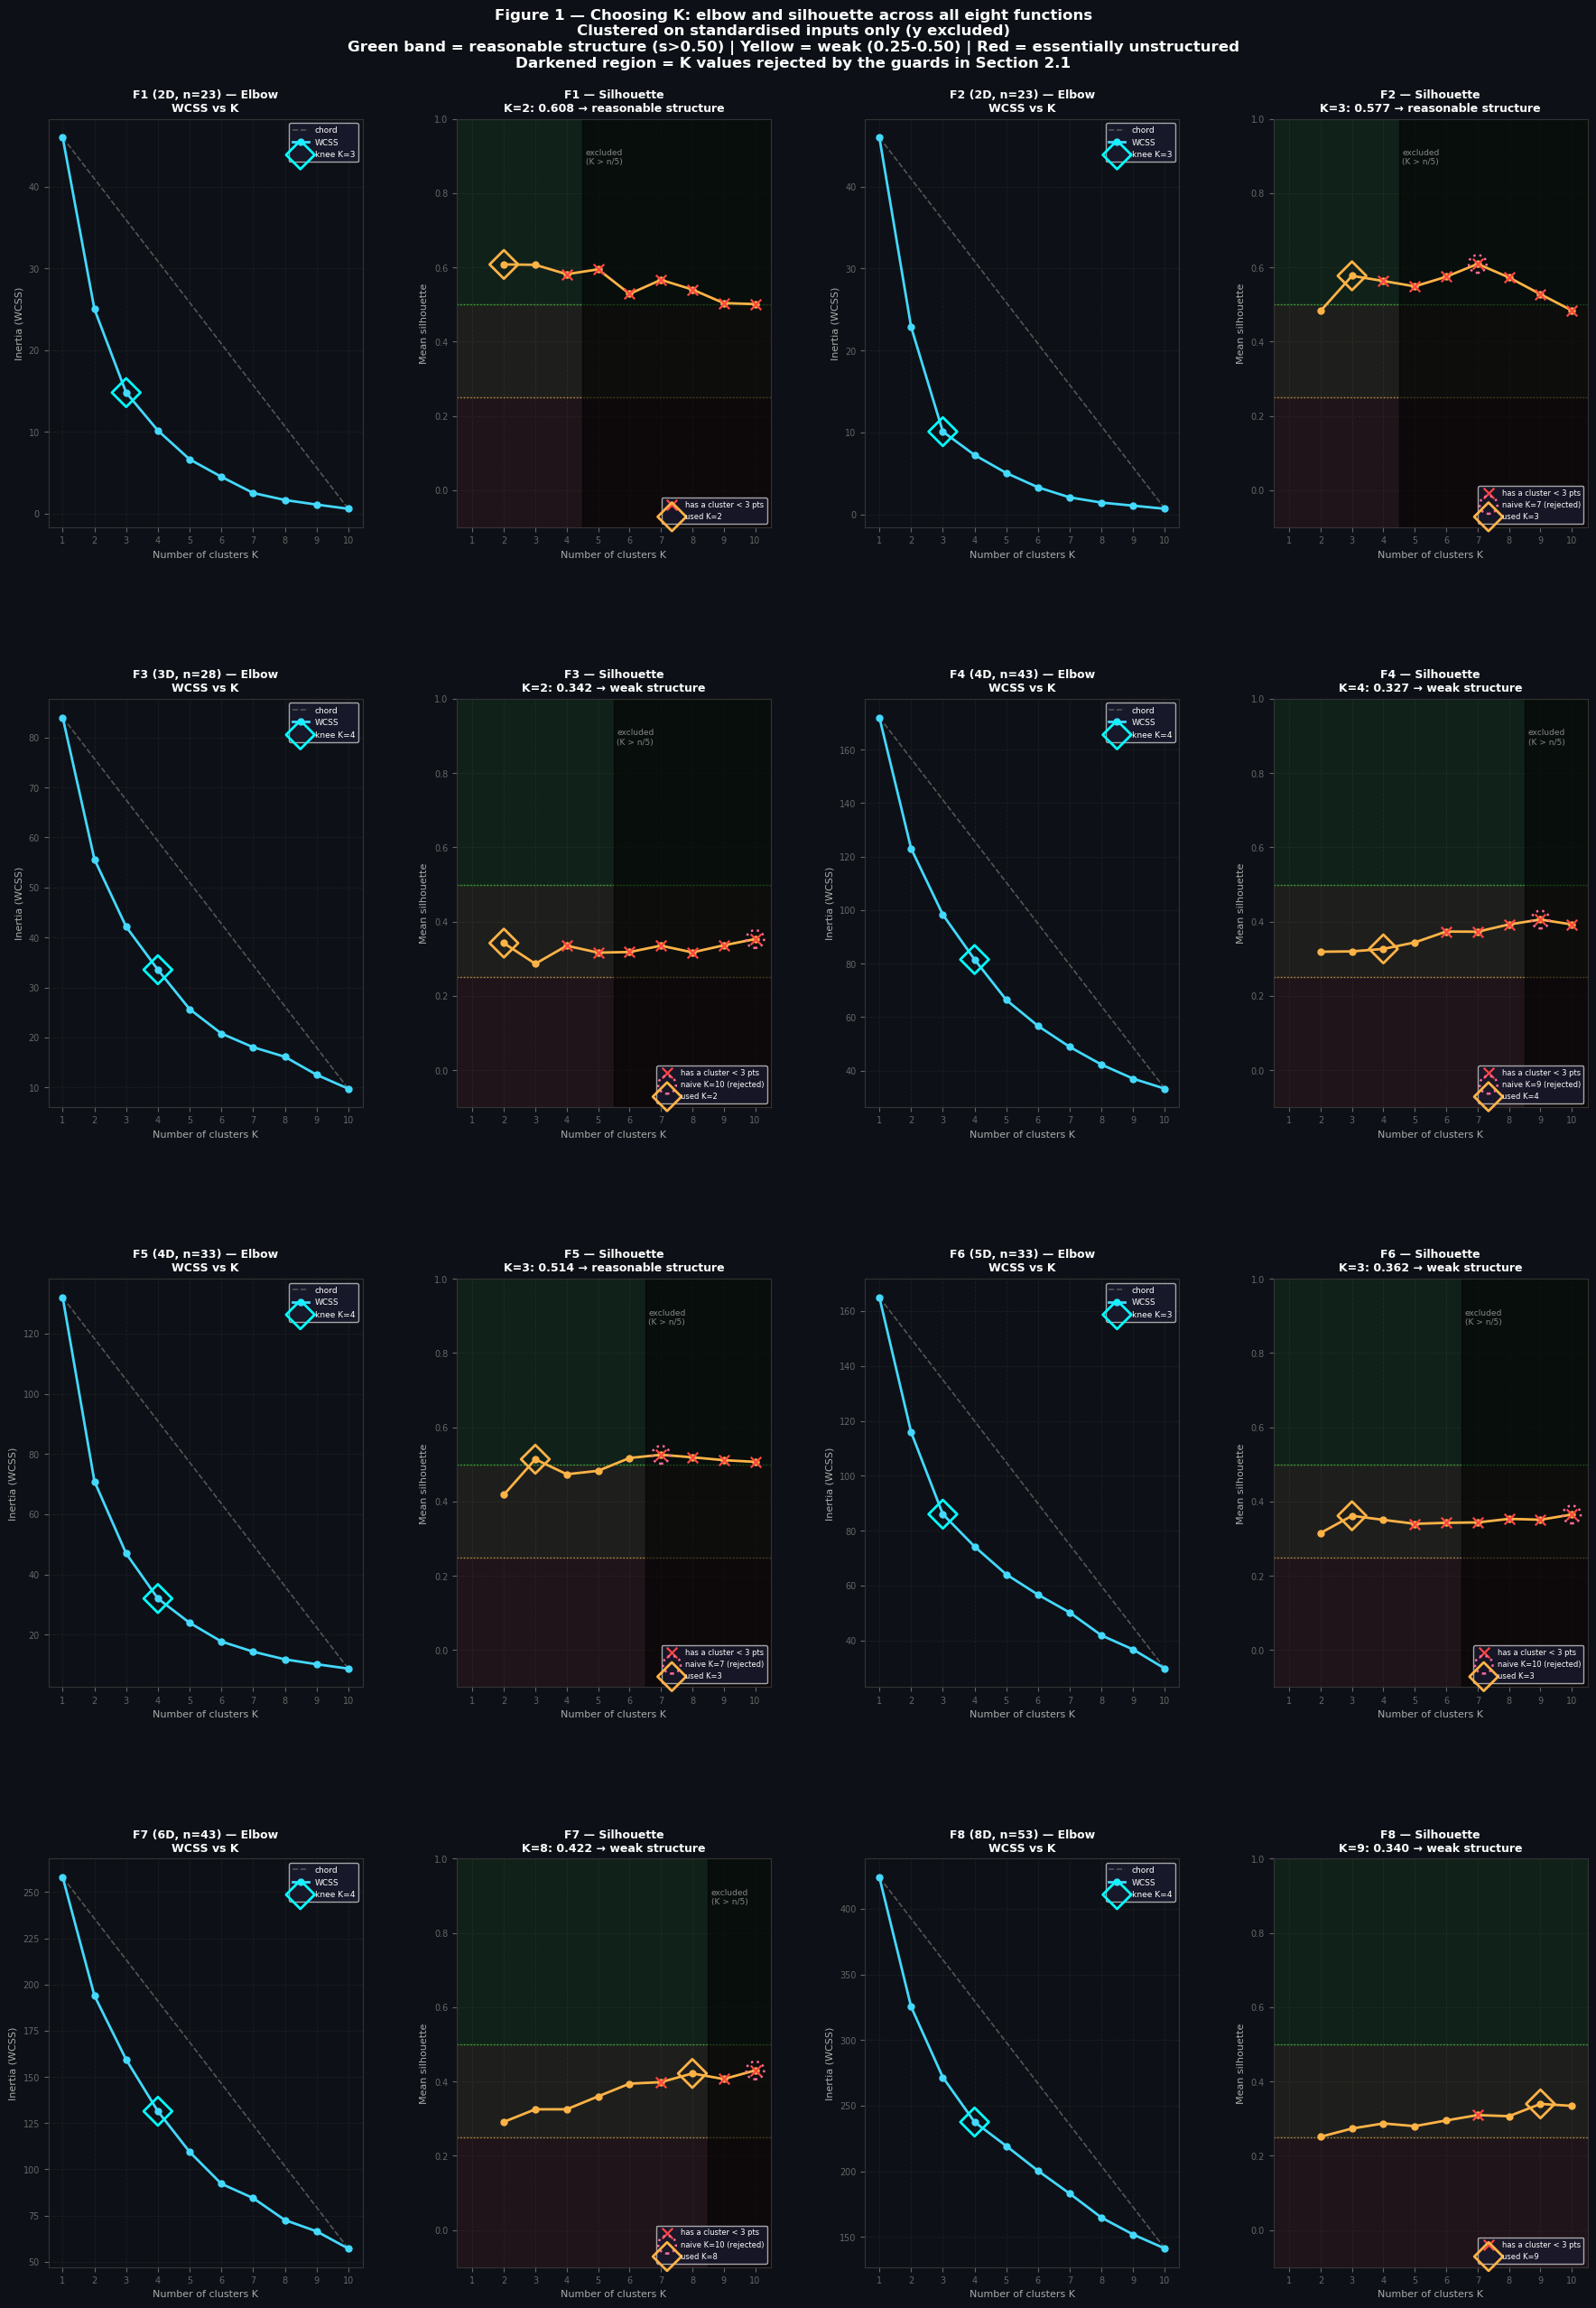

✓ Saved clustering_fig1_elbow_silhouette.png


In [6]:
fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.42, wspace=0.30,
                      top=0.945, bottom=0.030)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    s    = KSCAN[fid]
    ks, wcss, sil, msize = s['ks'], s['wcss'], s['sil'], s['msize']
    d    = DATA[fid]
    k_cap = max(2, len(d['y']) // AVG_POINTS_PER_K)

    # ── Elbow panel ────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[r, c * 2])
    style_ax(ax)
    ax.plot([ks[0], ks[-1]], [wcss[0], wcss[-1]],
            color='#555555', ls='--', lw=1.2, zorder=1, label='chord')
    ax.plot(ks, wcss, marker='o', color='#44d9ff', lw=2, ms=5,
            zorder=3, label='WCSS')
    ke = s['k_elbow']
    ax.scatter([ke], [wcss[list(ks).index(ke)]], s=260, marker='D',
               facecolor='none', edgecolor='cyan', lw=2, zorder=4,
               label=f'knee K={ke}')
    ax.set_title(f"F{fid} ({d['dim']}D, n={len(d['y'])}) — Elbow\nWCSS vs K",
                 color=TC, fontsize=9, fontweight='bold')
    ax.set_xlabel('Number of clusters K', color=AC, fontsize=8)
    ax.set_ylabel('Inertia (WCSS)', color=AC, fontsize=8)
    ax.set_xticks(ks)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='upper right')

    # ── Silhouette panel ───────────────────────────────────────────────────
    ax = fig.add_subplot(gs[r, c * 2 + 1])
    style_ax(ax)
    ax.axhspan(0.50, 1.00, color='#44ff44', alpha=0.07)
    ax.axhspan(0.25, 0.50, color='#ffe066', alpha=0.07)
    ax.axhspan(-0.10, 0.25, color='#ff4444', alpha=0.07)
    ax.axhline(0.50, color='#44ff44', ls=':', lw=1, alpha=0.6)
    ax.axhline(0.25, color='#ffe066', ls=':', lw=1, alpha=0.6)

    # Grey out the K values excluded by the guards in Section 2.1
    if k_cap < ks[-1]:
        ax.axvspan(k_cap + 0.5, ks[-1] + 0.5, color='#000000', alpha=0.55, zorder=2)
        ax.text(k_cap + 0.6, 0.92, 'excluded\n(K > n/5)', color='#888888',
                fontsize=6.5, va='top', zorder=5)

    m = ~np.isnan(sil)
    ax.plot(ks[m], sil[m], marker='o', color='#ffb347', lw=2, ms=5, zorder=3)

    # Mark small clusters, which is the other reason a K gets rejected
    tiny = m & (msize < MIN_CLUSTER_SIZE)
    if tiny.any():
        ax.scatter(ks[tiny], sil[tiny], s=70, marker='x', color=NOISE_COLOR,
                   lw=1.6, zorder=5, label=f'has a cluster < {MIN_CLUSTER_SIZE} pts')

    kn, kb = s['k_naive'], s['k_sel']
    if kn != kb:
        ax.scatter([kn], [sil[list(ks).index(kn)]], s=200, marker='o',
                   facecolor='none', edgecolor='#ff6b9d', lw=1.8, ls=':',
                   zorder=4, label=f'naive K={kn} (rejected)')
    ax.scatter([kb], [s['sil_sel']], s=260, marker='D', facecolor='none',
               edgecolor='#ffb347', lw=2, zorder=6, label=f'used K={kb}')

    ax.set_title(f"F{fid} — Silhouette\nK={kb}: {s['sil_sel']:.3f} → {silhouette_verdict(s['sil_sel'])}",
                 color=TC, fontsize=9, fontweight='bold')
    ax.set_xlabel('Number of clusters K', color=AC, fontsize=8)
    ax.set_ylabel('Mean silhouette', color=AC, fontsize=8)
    ax.set_xticks(ks)
    ax.set_xlim(0.5, ks[-1] + 0.5)
    ax.set_ylim(min(-0.10, float(np.nanmin(sil)) - 0.05), 1.0)
    ax.legend(fontsize=6, facecolor='#1a1a2e', labelcolor='white', loc='lower right')

fig.suptitle(
    'Figure 1 — Choosing K: elbow and silhouette across all eight functions\n'
    'Clustered on standardised inputs only (y excluded)\n'
    'Green band = reasonable structure (s>0.50) | Yellow = weak (0.25-0.50) | Red = essentially unstructured\n'
    'Darkened region = K values rejected by the guards in Section 2.1',
    color='white', fontsize=12, fontweight='bold', y=0.992)

plt.savefig('clustering_fig1_elbow_silhouette.png', dpi=140,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Saved clustering_fig1_elbow_silhouette.png')

**Reading Figure 1.**

The elbow curves are smooth for most functions — that smoothness *is* the result.
A sharp bend means "there are genuinely this many groups"; a gentle curve means the data
is one diffuse cloud and any $K$ you pick is a convenience, not a discovery.

Note how often the elbow and the silhouette disagree. That disagreement is not a defect
in either method; it reflects that they optimise different things. The elbow asks
*when do I stop paying for extra clusters?* The silhouette asks *are the clusters I have
actually separated?*

Look also at the darkened region on the right of each silhouette panel, and at the pink
circles where they appear. In several functions the silhouette is still climbing when the
sweep ends — the naive rule would have chased it all the way to $K=10$. What the guards
buy us is the ability to say clearly: *the score keeps rising, and we are declining to
follow it, because the partitions it is rewarding contain two points each.*

---
## Section 3 — K-Means on $\mathbf{X}$ alone: does geometry find the good region?

This is the central experiment of the notebook.

**Protocol.**
1. Fit K-Means on the standardised inputs only, at the $K$ chosen in Section 2.
   The model never sees $y$.
2. *Then* look at $y$ within each cluster.
3. Score the partition with $\eta^2$ — the share of $y$'s variance explained by
   the labels — and test it against 2000 label shuffles.

**How to read the outcome.**

- **Large $\eta^2$, small $p$** — the design geometry alone separates good from bad.
  The promising region is a contiguous blob that a convex partition can isolate.
  This is the result that would justify exploring a cluster's neighbourhood.
- **Small $\eta^2$, large $p$** — good and bad points are interleaved at the scale we
  have sampled. The landscape is rugged or the optimum is a narrow spike.
  Only the GP, which models the response surface rather than partitioning the domain,
  can make progress.

Both outcomes are informative. The second is more common, and reporting it honestly is
worth more than a strained claim of structure.

### Cell 7 — Fit K-Means on every function and score it against $y$

In [7]:
print('=' * 100)
print('  K-MEANS ON X ONLY — then scored against y (which the model never saw)')
print('=' * 100)

KM = {}       # fid -> dict(labels, km, k, eta2, pval, sil, profile, Z)

for fid in FIDS:
    d  = DATA[fid]
    Z  = KSCAN[fid]['Z']
    k  = K_CHOSEN[fid]

    km     = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    labels = km.labels_
    sil    = float(silhouette_score(Z, labels))
    eta, p = eta_squared_test(d['y'], labels)
    prof   = cluster_profile(fid, labels)

    KM[fid] = dict(labels=labels, km=km, k=k, eta2=eta, pval=p,
                   sil=sil, profile=prof, Z=Z)

    verdict = ('STRUCTURE FOUND — substantial and significant' if (p < 0.05 and eta > 0.25) else
               'significant, but a small effect'                if p < 0.05 else
               'borderline — does not clear the 5% bar'         if p < 0.10 else
               'no better than chance')

    print(f"\n{'─' * 100}")
    print(f"  F{fid} ({d['dim']}D, n={len(d['y'])}) — K={k}, silhouette={sil:.3f}")
    print(f"{'─' * 100}")
    print(f"    eta^2 = {eta:.3f}   (permutation p = {p:.4f})   →  {verdict}")
    print(f"    Interpretation: the cluster labels account for {eta*100:.1f}% "
          f"of the variance in y")
    print()
    show = prof[['rank', 'label', 'n', 'y_mean', 'y_std', 'y_min', 'y_max']].copy()
    for col in ['y_mean', 'y_std', 'y_min', 'y_max']:
        show[col] = show[col].map(lambda v: f'{v:.4f}')
    print(show.to_string(index=False))

    best = prof.iloc[0]
    worst = prof.iloc[-1]
    gap = best['y_mean'] - worst['y_mean']
    print(f"\n    Best cluster  {best['label']}: n={best['n']}, "
          f"mean y = {best['y_mean']:.4f}, best point = {best['best_x']}")
    print(f"    Worst cluster {worst['label']}: n={worst['n']}, "
          f"mean y = {worst['y_mean']:.4f}")
    print(f"    Separation in mean y: {gap:.4f} "
          f"({gap / (d['y'].std() + 1e-12):.2f} standard deviations)")

  K-MEANS ON X ONLY — then scored against y (which the model never saw)

────────────────────────────────────────────────────────────────────────────────────────────────────
  F1 (2D, n=23) — K=2, silhouette=0.608
────────────────────────────────────────────────────────────────────────────────────────────────────
    eta^2 = 0.084   (permutation p = 0.1844)   →  no better than chance
    Interpretation: the cluster labels account for 8.4% of the variance in y

 rank label  n  y_mean  y_std   y_min  y_max
    1    C0 20  0.6766 0.8065 -0.0036 2.0000
    2    C1  3 -0.0000 0.0000 -0.0000 0.0000

    Best cluster  C0: n=20, mean y = 0.6766, best point = [0.6285, 0.6285]
    Worst cluster C1: n=3, mean y = -0.0000
    Separation in mean y: 0.6766 (0.86 standard deviations)

────────────────────────────────────────────────────────────────────────────────────────────────────
  F2 (2D, n=23) — K=3, silhouette=0.577
──────────────────────────────────────────────────────────────────────────────

### Cell 8 — Figure 2: cluster outcome profiles

Eight panels, one per function. Each bar is a cluster, ordered by mean $y$ (best on the left),
with the individual observations scattered over it so you can see the spread rather than
trusting an average over four points.

The panel title carries the honest verdict: $\eta^2$ with its permutation $p$-value.
A green title means the partition explains a meaningful share of $y$ and survives the
shuffle test; grey means it does not.

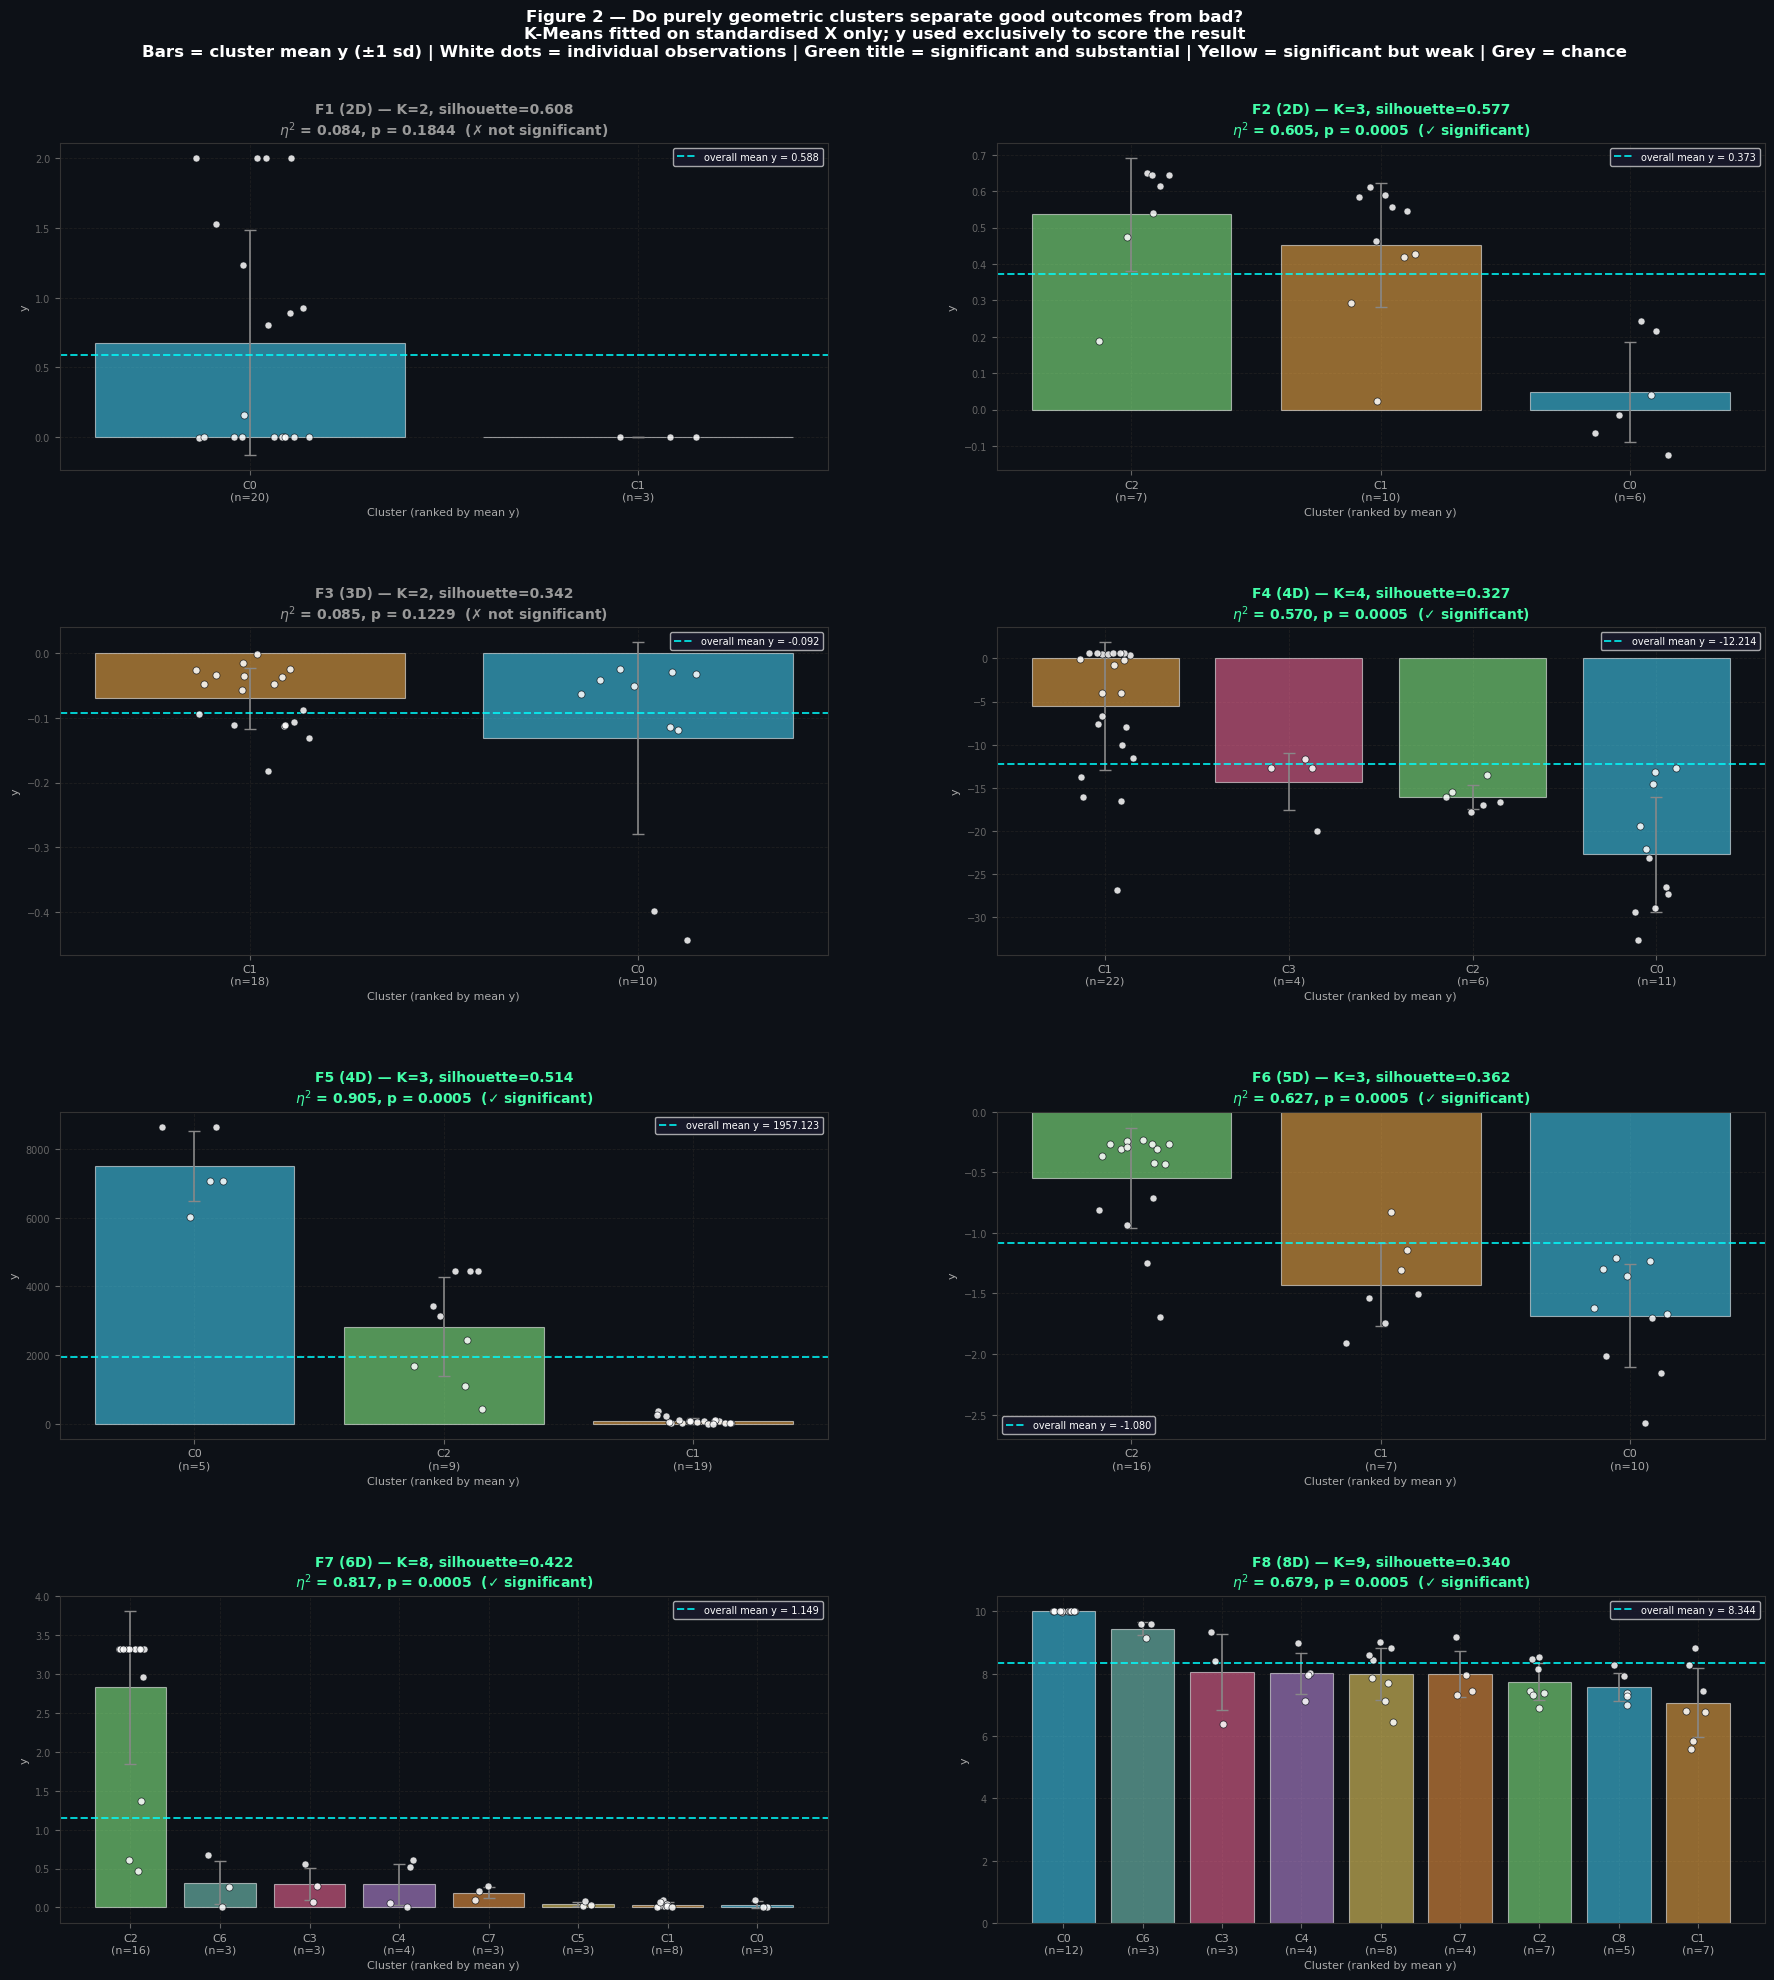

✓ Saved clustering_fig2_cluster_profiles.png


In [8]:
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.48, wspace=0.22,
                      top=0.925, bottom=0.035)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    ax = fig.add_subplot(gs[r, c])
    style_ax(ax)

    d    = DATA[fid]
    res  = KM[fid]
    prof = res['profile']
    y    = d['y']

    xpos = np.arange(len(prof))
    means = prof['y_mean'].to_numpy()
    stds  = prof['y_std'].to_numpy()
    cols  = [CLUSTER_COLORS[int(cl) % len(CLUSTER_COLORS)] for cl in prof['cluster']]

    ax.bar(xpos, means, yerr=stds, color=cols, alpha=0.55,
           edgecolor='white', lw=0.8, capsize=4,
           error_kw=dict(ecolor='#888888', lw=1.2))

    # individual observations, jittered
    rng = np.random.default_rng(RANDOM_STATE)
    for i, cl in enumerate(prof['cluster']):
        vals = y[res['labels'] == cl]
        jit  = rng.uniform(-0.16, 0.16, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jit, vals, s=26, zorder=5,
                   color='white', edgecolor='#0d1117', lw=0.5, alpha=0.85)

    ax.axhline(y.mean(), color='cyan', ls='--', lw=1.4, alpha=0.8,
               label=f'overall mean y = {y.mean():.3f}')
    ax.set_xticks(xpos)
    ax.set_xticklabels([f"{l}\n(n={n})" for l, n in zip(prof['label'], prof['n'])],
                       color=AC, fontsize=8)

    sig = res['pval'] < 0.05
    title_col = '#44ffaa' if (sig and res['eta2'] > 0.25) else \
                '#ffe066' if sig else '#999999'
    star = '✓ significant' if sig else '✗ not significant'
    ax.set_title(f"F{fid} ({d['dim']}D) — K={res['k']}, silhouette={res['sil']:.3f}\n"
                 f"$\\eta^2$ = {res['eta2']:.3f}, p = {res['pval']:.4f}  ({star})",
                 color=title_col, fontsize=10, fontweight='bold')
    ax.set_ylabel('y', color=AC, fontsize=8)
    ax.set_xlabel('Cluster (ranked by mean y)', color=AC, fontsize=8)
    ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white', loc='best')

fig.suptitle(
    'Figure 2 — Do purely geometric clusters separate good outcomes from bad?\n'
    'K-Means fitted on standardised X only; y used exclusively to score the result\n'
    'Bars = cluster mean y (±1 sd) | White dots = individual observations | '
    'Green title = significant and substantial | Yellow = significant but weak | Grey = chance',
    color='white', fontsize=12, fontweight='bold', y=0.992)

plt.savefig('clustering_fig2_cluster_profiles.png', dpi=140,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Saved clustering_fig2_cluster_profiles.png')

---
## Section 4 — Seeing the partition: PCA projection gallery

F1 and F2 are 2D and can be plotted directly. The rest cannot, so we project onto the
first two principal components — the two orthogonal directions carrying the most variance.

**Read the explained-variance figure in every panel title before believing the picture.**
For F8 (8D), two components typically retain only a third of the variance: two points that
look adjacent in the projection may be far apart in the other six dimensions. The projection
is a shadow, and shadows lose information.

Each function gets two panels:
- **Left** — coloured by cluster label, with centroids marked ✕
- **Right** — the same coordinates coloured by actual $y$ (viridis, bright = high)

Compare them. If the left-hand colour blocks line up with the right-hand bright region,
geometry found the optimum. If the bright points are scattered across every cluster,
it did not — and that is exactly the situation the $\eta^2$ test in Section 3 quantified.

### Cell 9 — Figure 3: PCA gallery

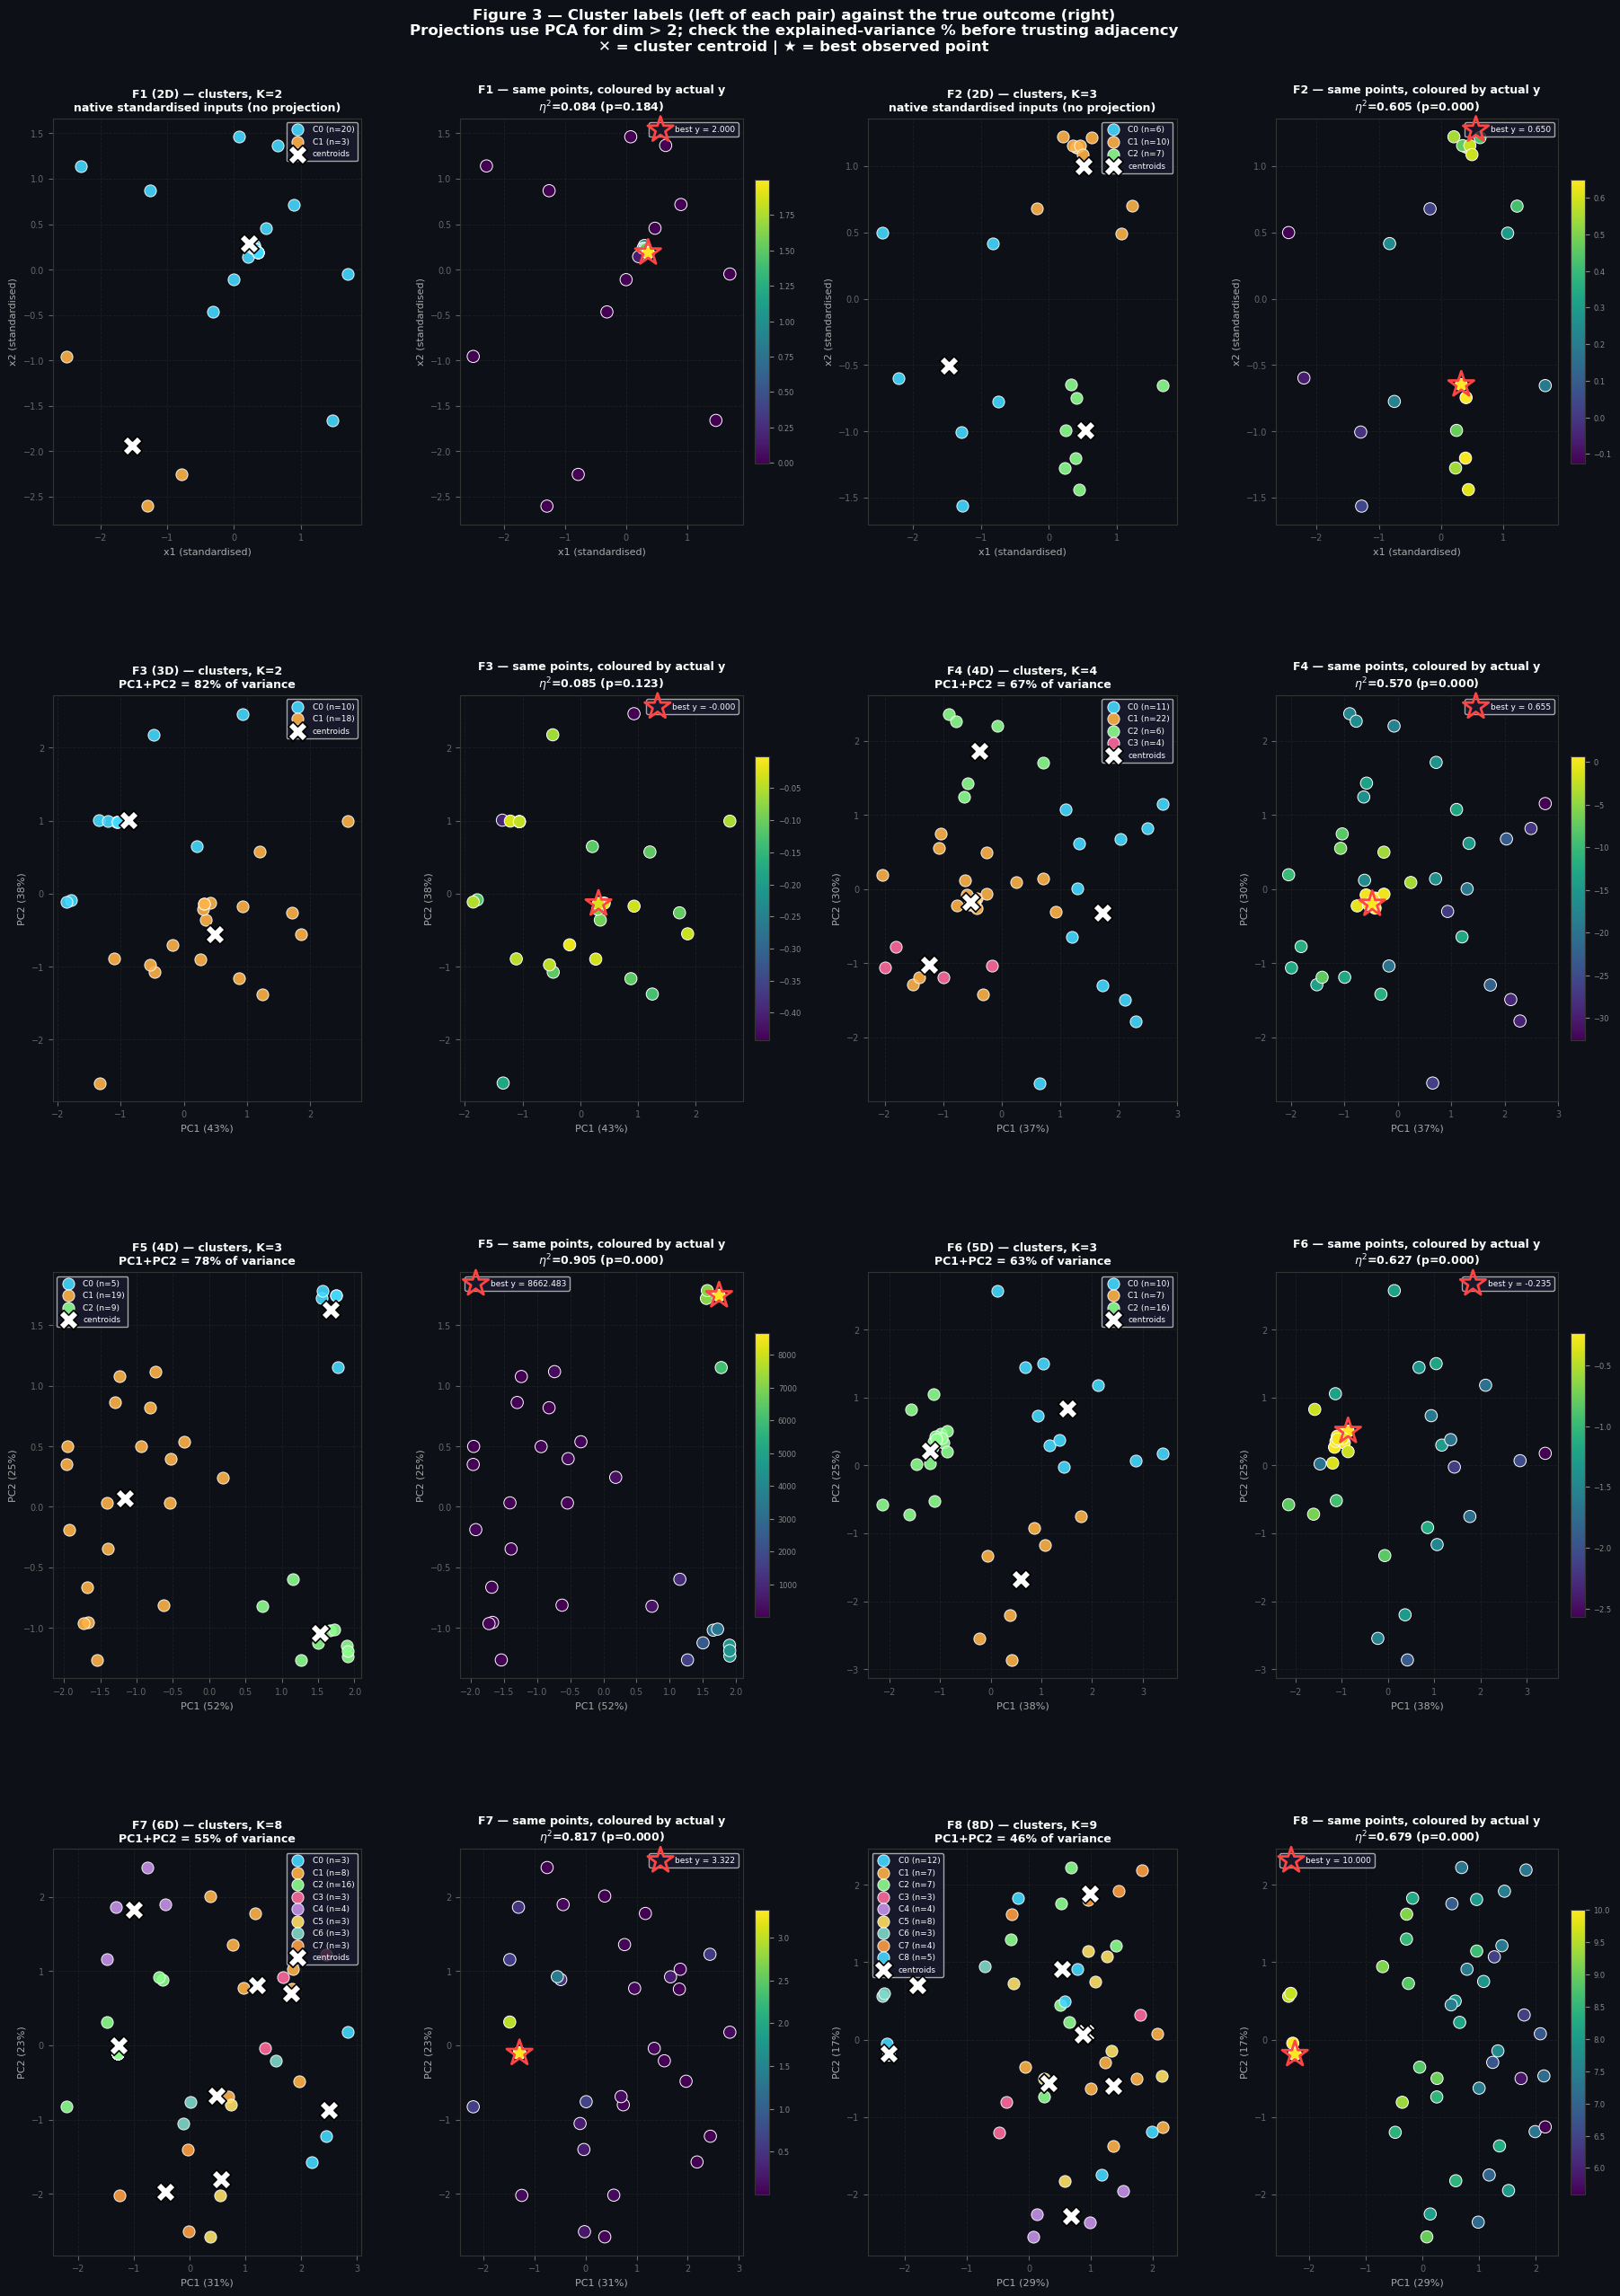

✓ Saved clustering_fig3_pca_gallery.png

  PCA variance retained by the first two components:
    F1 (2D): n/a — plotted in native coordinates, nothing lost
    F2 (2D): n/a — plotted in native coordinates, nothing lost
    F3 (3D):  81.8%
    F4 (4D):  66.9%
    F5 (4D):  77.6%
    F6 (5D):  62.8%
    F7 (6D):  54.9%  ⚠ projection loses most of the structure
    F8 (8D):  45.9%  ⚠ projection loses most of the structure


In [9]:
fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.42, wspace=0.32,
                      top=0.945, bottom=0.030)

PCA_INFO = {}

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    d      = DATA[fid]
    res    = KM[fid]
    Z      = res['Z']
    labels = res['labels']

    # 2D functions are plotted in their own standardised coordinates — PCA would
    # only rotate them, and a rotation makes the axes harder to interpret for no gain.
    if d['dim'] == 2:
        coords, evr = Z[:, :2], None
        lab_x, lab_y = 'x1 (standardised)', 'x2 (standardised)'
        axis_note = 'native standardised inputs (no projection)'
    else:
        coords, evr = pca_2d(Z)
        lab_x = f'PC1 ({evr[0]*100:.0f}%)'
        lab_y = f'PC2 ({evr[1]*100:.0f}%)'
        axis_note = f'PC1+PC2 = {evr.sum()*100:.0f}% of variance'
    PCA_INFO[fid] = (coords, evr, lab_x, lab_y)
    cen = np.vstack([coords[labels == cl].mean(axis=0) for cl in np.unique(labels)])

    # ── Panel A: coloured by cluster ───────────────────────────────────────
    ax = fig.add_subplot(gs[r, c * 2])
    style_ax(ax)
    for cl in np.unique(labels):
        m = labels == cl
        ax.scatter(coords[m, 0], coords[m, 1], s=90, alpha=0.9,
                   color=CLUSTER_COLORS[int(cl) % len(CLUSTER_COLORS)],
                   edgecolor='white', lw=0.7, label=f'C{cl} (n={m.sum()})')
    ax.scatter(cen[:, 0], cen[:, 1], marker='X', s=240, c='white',
               edgecolor='black', lw=1.2, zorder=6, label='centroids')

    ax.set_title(f"F{fid} ({d['dim']}D) — clusters, K={res['k']}\n{axis_note}",
                 color=TC, fontsize=9, fontweight='bold')
    ax.set_xlabel(lab_x, color=AC, fontsize=8)
    ax.set_ylabel(lab_y, color=AC, fontsize=8)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='best')

    # ── Panel B: coloured by y ─────────────────────────────────────────────
    ax = fig.add_subplot(gs[r, c * 2 + 1])
    style_ax(ax)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=d['y'], cmap='viridis',
                    s=95, edgecolor='white', lw=0.7)
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(colors='#888888', labelsize=6)
    cb.outline.set_edgecolor('#333333')

    b = int(np.argmax(d['y']))
    ax.scatter([coords[b, 0]], [coords[b, 1]], marker='*', s=460,
               facecolor='none', edgecolor='#ff4444', lw=2, zorder=7,
               label=f'best y = {d["y"][b]:.3f}')
    ax.set_title(f"F{fid} — same points, coloured by actual y\n"
                 f"$\\eta^2$={res['eta2']:.3f} (p={res['pval']:.3f})",
                 color=TC, fontsize=9, fontweight='bold')
    ax.set_xlabel(lab_x, color=AC, fontsize=8)
    ax.set_ylabel(lab_y, color=AC, fontsize=8)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='best')

fig.suptitle(
    'Figure 3 — Cluster labels (left of each pair) against the true outcome (right)\n'
    'Projections use PCA for dim > 2; check the explained-variance % before trusting adjacency\n'
    '✕ = cluster centroid | ★ = best observed point',
    color='white', fontsize=12, fontweight='bold', y=0.992)

plt.savefig('clustering_fig3_pca_gallery.png', dpi=140,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Saved clustering_fig3_pca_gallery.png')

print('\n  PCA variance retained by the first two components:')
for fid in FIDS:
    evr = PCA_INFO[fid][1]
    if evr is None:
        print(f'    F{fid} ({DATA[fid]["dim"]}D): n/a — plotted in native coordinates, nothing lost')
        continue
    warn = '  ⚠ projection loses most of the structure' if evr.sum() < 0.60 else ''
    print(f'    F{fid} ({DATA[fid]["dim"]}D): {evr.sum()*100:5.1f}%{warn}')

---
## Section 5 — Hierarchical clustering: the dendrogram view

K-Means demands $K$ up front. Hierarchical clustering does not: it builds the entire merge
tree, and you choose where to cut afterwards. That makes it the better *exploratory* tool —
you can see whether a natural cut exists rather than imposing one.

**Ward linkage** is used throughout, merging the pair of clusters that increases total
within-cluster variance least. It is the hierarchical analogue of the K-Means objective,
which keeps this section comparable with Sections 2–4.

**Reading a dendrogram.**
- Height of a horizontal link = cost of that merge. Tall links join genuinely distinct groups.
- A long vertical gap with no merges = a natural place to cut.
- Uniformly short links, merging steadily all the way up = one diffuse cloud, no real groups.

The **cophenetic correlation** in each title measures how faithfully the tree preserves the
original pairwise distances. Above $\approx 0.75$ the dendrogram is a fair summary of the
geometry; well below that, it is distorting distances to force a hierarchy.

### Cell 10 — Figure 4: dendrogram gallery

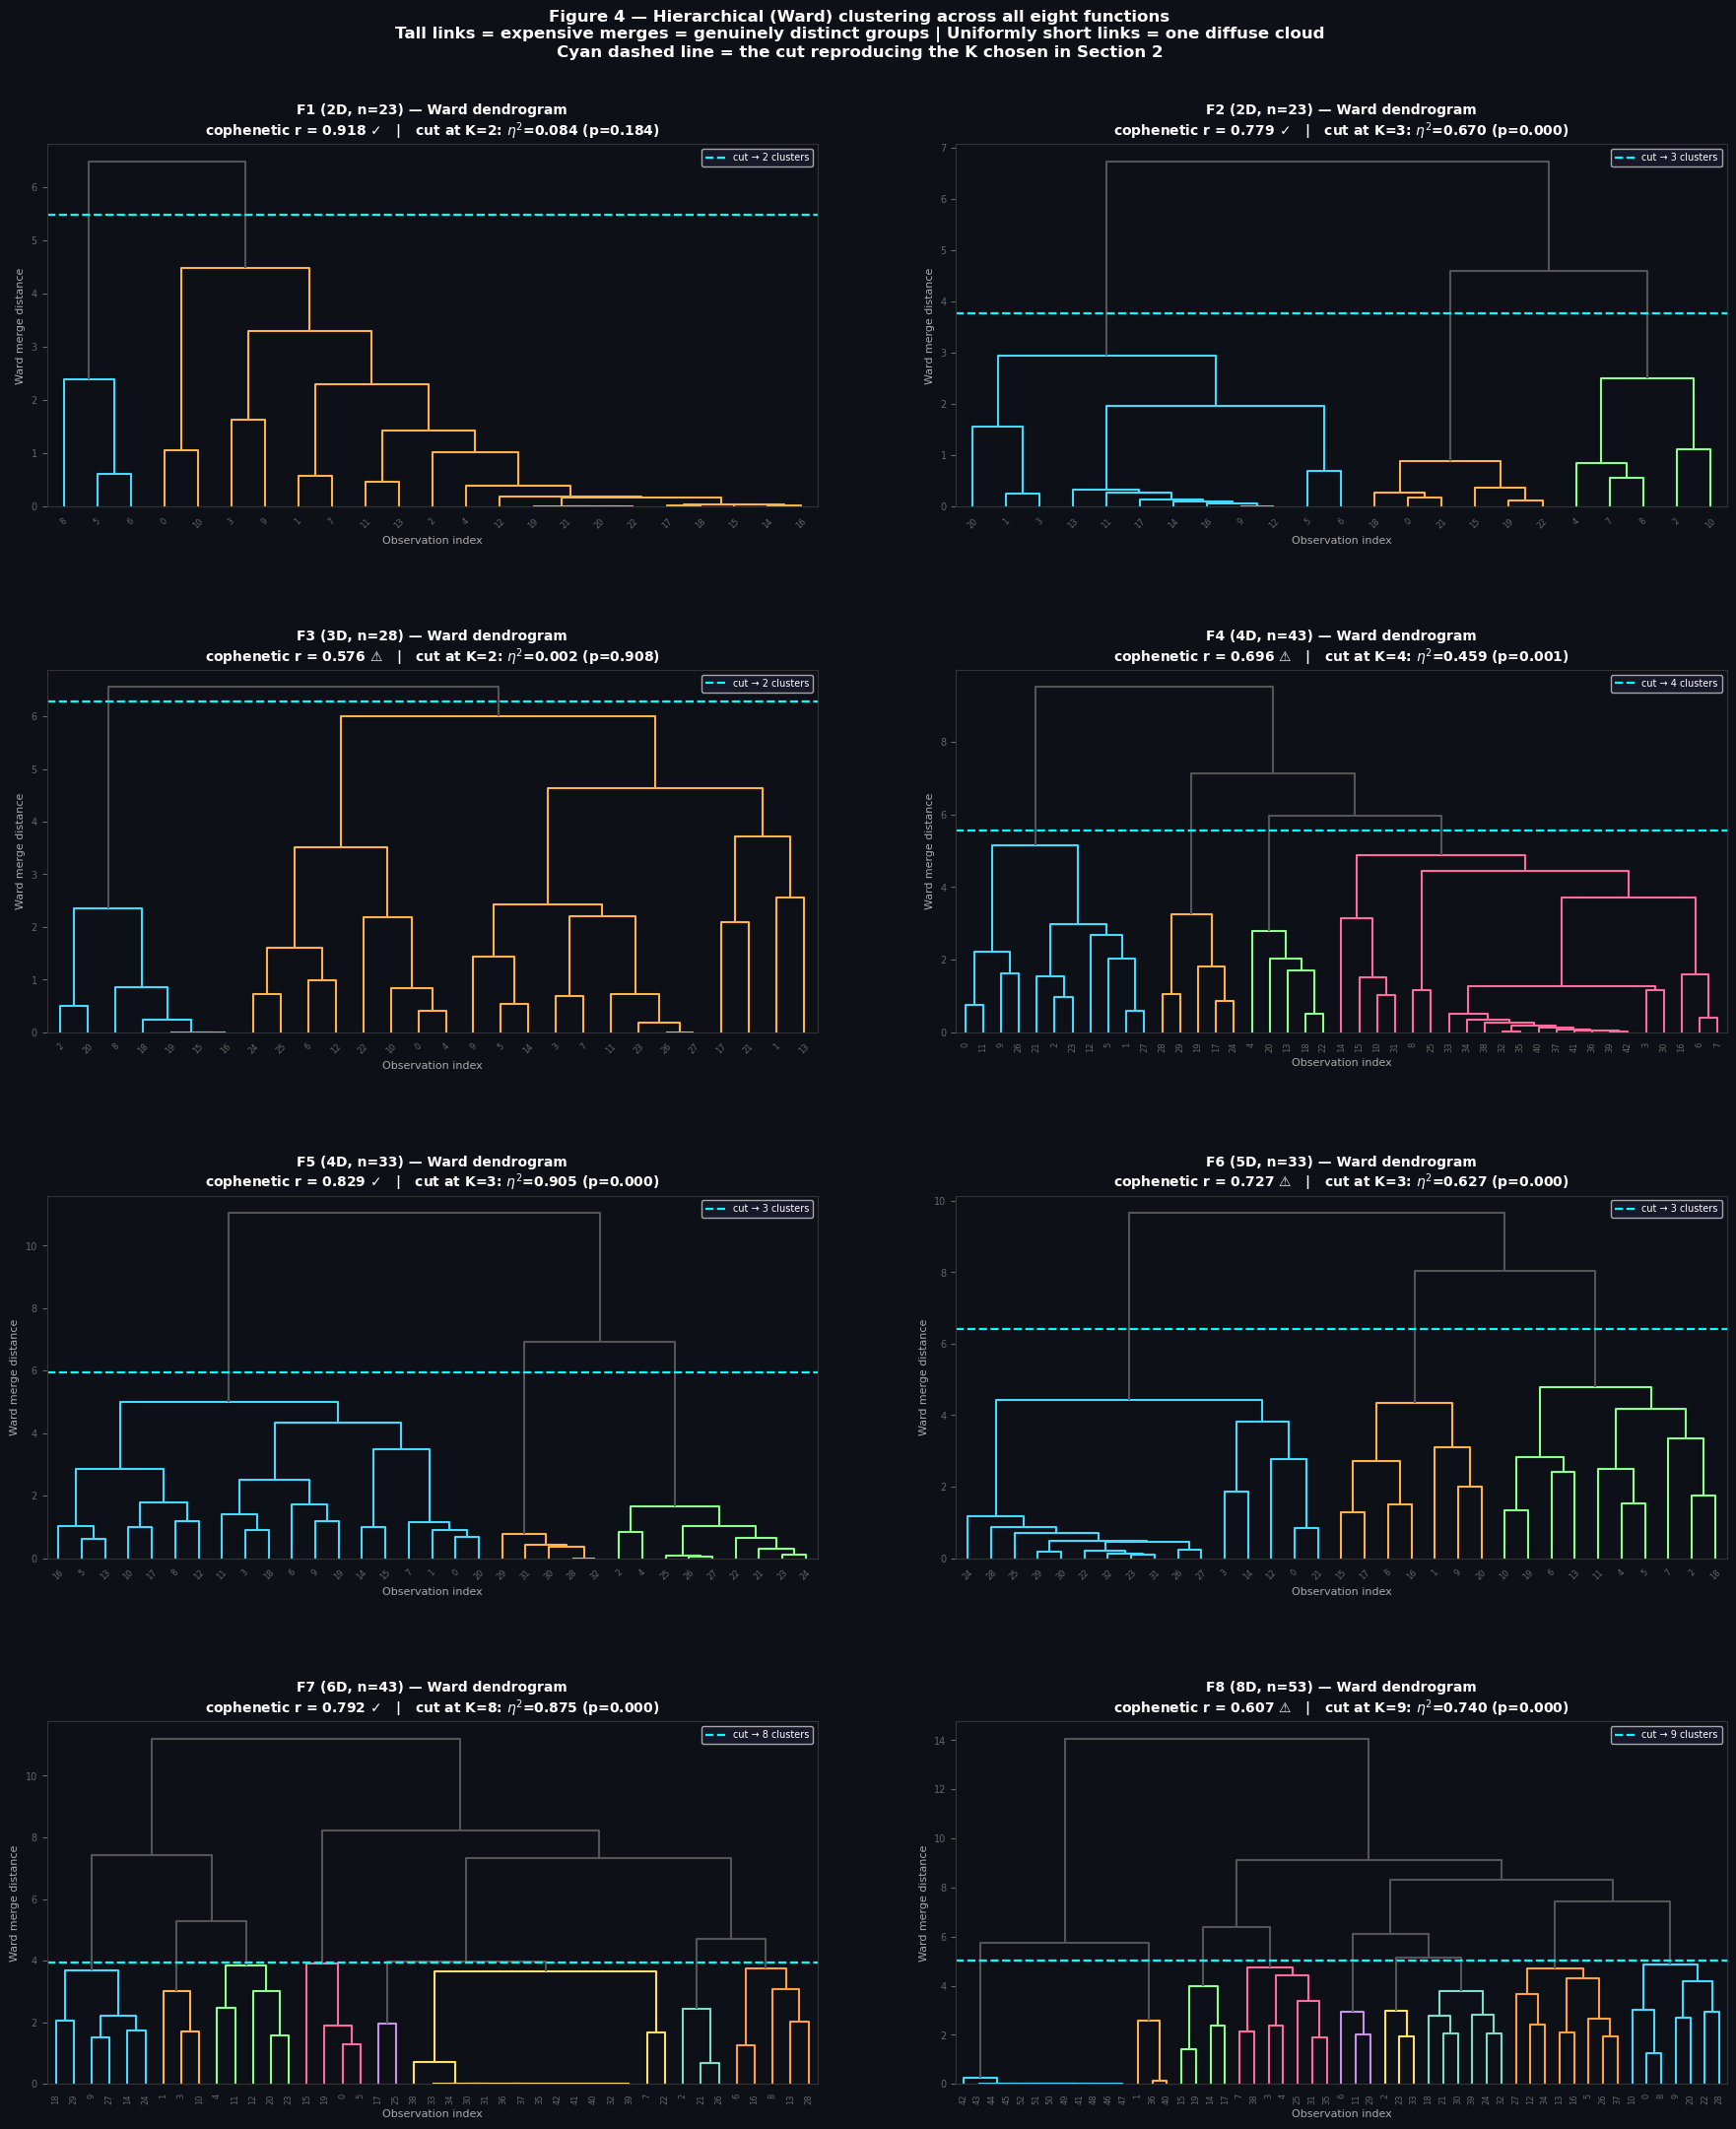

✓ Saved clustering_fig4_dendrograms.png


In [10]:
fig = plt.figure(figsize=(22, 22))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.18,
                      top=0.930, bottom=0.035)

HIER = {}

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    ax = fig.add_subplot(gs[r, c])
    style_ax(ax)
    ax.grid(False)

    d = DATA[fid]
    Z = KM[fid]['Z']
    k = K_CHOSEN[fid]

    L      = linkage(Z, method='ward')
    coph, _ = cophenet(L, pdist(Z))

    # Colour threshold that yields exactly k groups: midway between the
    # (k-1)th and kth largest merge heights.
    heights = np.sort(L[:, 2])
    thresh  = (heights[-(k - 1)] + heights[-k]) / 2 if k >= 2 and len(heights) >= k else heights[-1]

    shc.set_link_color_palette(CLUSTER_COLORS)
    shc.dendrogram(L, ax=ax, color_threshold=thresh,
                   above_threshold_color='#555555',
                   leaf_font_size=6)
    ax.axhline(thresh, color='cyan', ls='--', lw=1.6,
               label=f'cut → {k} clusters')

    labels_h = fcluster(L, t=k, criterion='maxclust')
    eta_h, p_h = eta_squared_test(d['y'], labels_h - 1)
    agree = (len(np.unique(labels_h)) ==
             len(np.unique(KM[fid]['labels'])))
    HIER[fid] = dict(linkage=L, coph=float(coph), labels=labels_h - 1,
                     eta2=eta_h, pval=p_h, thresh=float(thresh))

    coph_flag = '✓' if coph >= 0.75 else '⚠'
    ax.set_title(f"F{fid} ({d['dim']}D, n={len(d['y'])}) — Ward dendrogram\n"
                 f"cophenetic r = {coph:.3f} {coph_flag}   |   "
                 f"cut at K={k}: $\\eta^2$={eta_h:.3f} (p={p_h:.3f})",
                 color=TC, fontsize=10, fontweight='bold')
    ax.set_xlabel('Observation index', color=AC, fontsize=8)
    ax.set_ylabel('Ward merge distance', color=AC, fontsize=8)
    ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white', loc='upper right')

shc.set_link_color_palette(None)

fig.suptitle(
    'Figure 4 — Hierarchical (Ward) clustering across all eight functions\n'
    'Tall links = expensive merges = genuinely distinct groups | '
    'Uniformly short links = one diffuse cloud\n'
    'Cyan dashed line = the cut reproducing the K chosen in Section 2',
    color='white', fontsize=12, fontweight='bold', y=0.992)

plt.savefig('clustering_fig4_dendrograms.png', dpi=140,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Saved clustering_fig4_dendrograms.png')

### Cell 11 — K-Means vs hierarchical: do the two methods agree?

Two different algorithms, the same data and the same $K$. If they produce similar partitions,
whatever structure exists is robust to the choice of method. If they diverge sharply,
the partition is an artefact of the algorithm rather than a property of the data —
which is itself worth knowing before anyone builds a strategy on it.

Agreement is measured with the **adjusted Rand index**: $1.0$ is identical partitions,
$0.0$ is the level of overlap you would expect from two random labellings.

In [11]:
from sklearn.metrics import adjusted_rand_score

print('=' * 92)
print('  K-MEANS vs HIERARCHICAL (Ward) — partition agreement')
print('=' * 92)

rows = []
for fid in FIDS:
    ari = adjusted_rand_score(KM[fid]['labels'], HIER[fid]['labels'])
    rows.append({
        'Function':      f'F{fid}',
        'Dim':           DATA[fid]['dim'],
        'K':             K_CHOSEN[fid],
        'ARI':           round(float(ari), 3),
        'KM eta^2':      round(KM[fid]['eta2'], 3),
        'KM p':          round(KM[fid]['pval'], 4),
        'Ward eta^2':    round(HIER[fid]['eta2'], 3),
        'Ward p':        round(HIER[fid]['pval'], 4),
        'Cophenetic':    round(HIER[fid]['coph'], 3),
        'Agreement':     'strong'   if ari >= 0.70 else
                         'moderate' if ari >= 0.40 else 'weak',
    })

AGREE_TABLE = pd.DataFrame(rows)
print(AGREE_TABLE.to_string(index=False))

print('\n  Reading this table:')
print('    ARI ≈ 1.0  → both algorithms recovered the same groups; structure is method-independent')
print('    ARI < 0.4  → the partition depends on the algorithm, so treat it as an artefact')
print('    Compare KM eta^2 with Ward eta^2: if one is significant and the other is not,')
print('    the y-separation is not a stable property of the data.')

  K-MEANS vs HIERARCHICAL (Ward) — partition agreement
Function  Dim  K   ARI  KM eta^2   KM p  Ward eta^2  Ward p  Cophenetic Agreement
      F1    2  2 1.000     0.084 0.1844       0.084  0.1844       0.918    strong
      F2    2  3 0.719     0.605 0.0005       0.670  0.0005       0.779    strong
      F3    3  2 0.599     0.085 0.1229       0.002  0.9080       0.576  moderate
      F4    4  4 0.825     0.570 0.0005       0.459  0.0010       0.696    strong
      F5    4  3 1.000     0.905 0.0005       0.905  0.0005       0.829    strong
      F6    5  3 1.000     0.627 0.0005       0.627  0.0005       0.727    strong
      F7    6  8 0.819     0.817 0.0005       0.875  0.0005       0.792    strong
      F8    8  9 0.869     0.679 0.0005       0.740  0.0005       0.607    strong

  Reading this table:
    ARI ≈ 1.0  → both algorithms recovered the same groups; structure is method-independent
    ARI < 0.4  → the partition depends on the algorithm, so treat it as an artefact
    Comp

---
## Section 6 — The instructive mistake: clustering on $[\mathbf{X} \mid y]$

An early version of this analysis appended $y$ to the feature matrix and clustered on
$[\mathbf{X} \mid y]$. The resulting clusters separated outcomes beautifully. It is worth
understanding exactly why that was guaranteed in advance, because it is one of the easiest
mistakes to make in unsupervised learning and one of the hardest to spot in a finished plot.

### 6.1 Why the result is circular

Include $y$ as a column, and K-Means minimises squared distance in a space that *contains* $y$.
Points with similar $y$ are close in that space by construction. So the clusters separate on $y$ —
and then we "discover" that they separate on $y$.

The $\eta^2$ will be high. The $p$-value will be tiny. And the finding is worth nothing,
because no new information was extracted: we put the answer into the input and read it back out.

This is not quite the same thing as supervised learning, which at least holds out a test set.
It is closer to circular reasoning with a colour palette.

**When is $[\mathbf{X} \mid y]$ legitimate?** When your goal is *description* rather than
*discovery* — segmenting observations into "good region / bad region" groups for a summary
table, where you already accept that $y$ drives the split. What it cannot do is answer
"does the input geometry predict the outcome?", because it assumes the answer.

### 6.2 The second problem: scale

If $y$ is appended **without standardising**, it does not merely participate in the distance —
it *is* the distance. Recall from Cell 3 that F5's outputs span four orders of magnitude more
than its inputs, which are confined to $[0,1]$. Squared Euclidean distance between two points
is then dominated by the $y$ term to the point where the $x$ columns are numerically irrelevant.

The cell below quantifies this per function: the share of total variance in the raw
$[\mathbf{X} \mid y]$ matrix contributed by the $y$ column alone.

### Cell 12 — Three-way comparison: X only, standardised $[X|y]$, raw $[X|y]$

In [12]:
print('=' * 104)
print('  EXPERIMENT — what happens when y enters the feature matrix')
print('=' * 104)

LEAK = {}

for fid in FIDS:
    d = DATA[fid]
    k = K_CHOSEN[fid]

    # (A) X only — the honest setup used everywhere else in this notebook
    Za = KM[fid]['Z']
    la = KM[fid]['labels']
    eta_a, p_a = KM[fid]['eta2'], KM[fid]['pval']
    sil_a = KM[fid]['sil']

    # (B) [X | y], standardised — y is one column among d+1
    Zb, _, _ = get_matrix(fid, include_y=True)
    kmb = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Zb)
    lb  = kmb.labels_
    eta_b, p_b = eta_squared_test(d['y'], lb)
    sil_b = float(silhouette_score(Zb, lb))

    # (C) [X | y] with NO standardisation — the scale trap
    Mc  = np.column_stack([d['X'], d['y']])
    kmc = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Mc)
    lc  = kmc.labels_
    eta_c, p_c = eta_squared_test(d['y'], lc)
    sil_c = float(silhouette_score(Mc, lc))

    # How much of the raw matrix's variance is just the y column?
    var_share = float(Mc.var(axis=0)[-1] / Mc.var(axis=0).sum())

    LEAK[fid] = dict(eta_a=eta_a, p_a=p_a, sil_a=sil_a,
                     eta_b=eta_b, p_b=p_b, sil_b=sil_b,
                     eta_c=eta_c, p_c=p_c, sil_c=sil_c,
                     var_share=var_share,
                     ari_ab=float(adjusted_rand_score(la, lb)),
                     ari_bc=float(adjusted_rand_score(lb, lc)))

LEAK_TABLE = pd.DataFrame([{
    'Function':        f'F{fid}',
    'Dim':             DATA[fid]['dim'],
    'K':               K_CHOSEN[fid],
    'eta2 (X only)':   round(LEAK[fid]['eta_a'], 3),
    'p (X only)':      round(LEAK[fid]['p_a'], 4),
    'eta2 (X|y std)':  round(LEAK[fid]['eta_b'], 3),
    'eta2 (X|y raw)':  round(LEAK[fid]['eta_c'], 3),
    'y var share':     f"{LEAK[fid]['var_share']*100:.1f}%",
    'ARI A vs B':      round(LEAK[fid]['ari_ab'], 3),
} for fid in FIDS])

print(LEAK_TABLE.to_string(index=False))

print('\n' + '─' * 104)
print('  The y-variance share is the headline number.')
print('─' * 104)
for fid in FIDS:
    s = LEAK[fid]['var_share']
    flag = ('  ← y IS the distance; x columns are numerically irrelevant' if s > 0.99 else
            '  ← y dominates'      if s > 0.90 else
            '  ← y contributes materially' if s > 0.50 else '')
    print(f"    F{fid}: y accounts for {s*100:6.2f}% of the raw matrix variance{flag}")

print('\n  Average eta^2 across the eight functions:')
print(f"    X only          : {np.nanmean([LEAK[f]['eta_a'] for f in FIDS]):.3f}   ← a real finding")
print(f"    [X|y] standard. : {np.nanmean([LEAK[f]['eta_b'] for f in FIDS]):.3f}   ← inflated by construction")
print(f"    [X|y] raw       : {np.nanmean([LEAK[f]['eta_c'] for f in FIDS]):.3f}   ← almost pure y, near-meaningless")

  EXPERIMENT — what happens when y enters the feature matrix
Function  Dim  K  eta2 (X only)  p (X only)  eta2 (X|y std)  eta2 (X|y raw) y var share  ARI A vs B
      F1    2  2          0.084      0.1844           0.198           0.840       89.1%       0.472
      F2    2  3          0.605      0.0005           0.746           0.746       28.9%       0.862
      F3    3  2          0.085      0.1229           0.085           0.085        4.6%       1.000
      F4    4  4          0.570      0.0005           0.734           0.950       99.7%       0.748
      F5    4  3          0.905      0.0005           0.905           0.951      100.0%       1.000
      F6    5  3          0.627      0.0005           0.627           0.853       55.5%       1.000
      F7    6  8          0.817      0.0005           0.950           0.988       83.3%       0.800
      F8    8  9          0.679      0.0005           0.807           0.961       71.2%       0.615

──────────────────────────────────────

### Cell 13 — Figure 5: the same data, three feature matrices

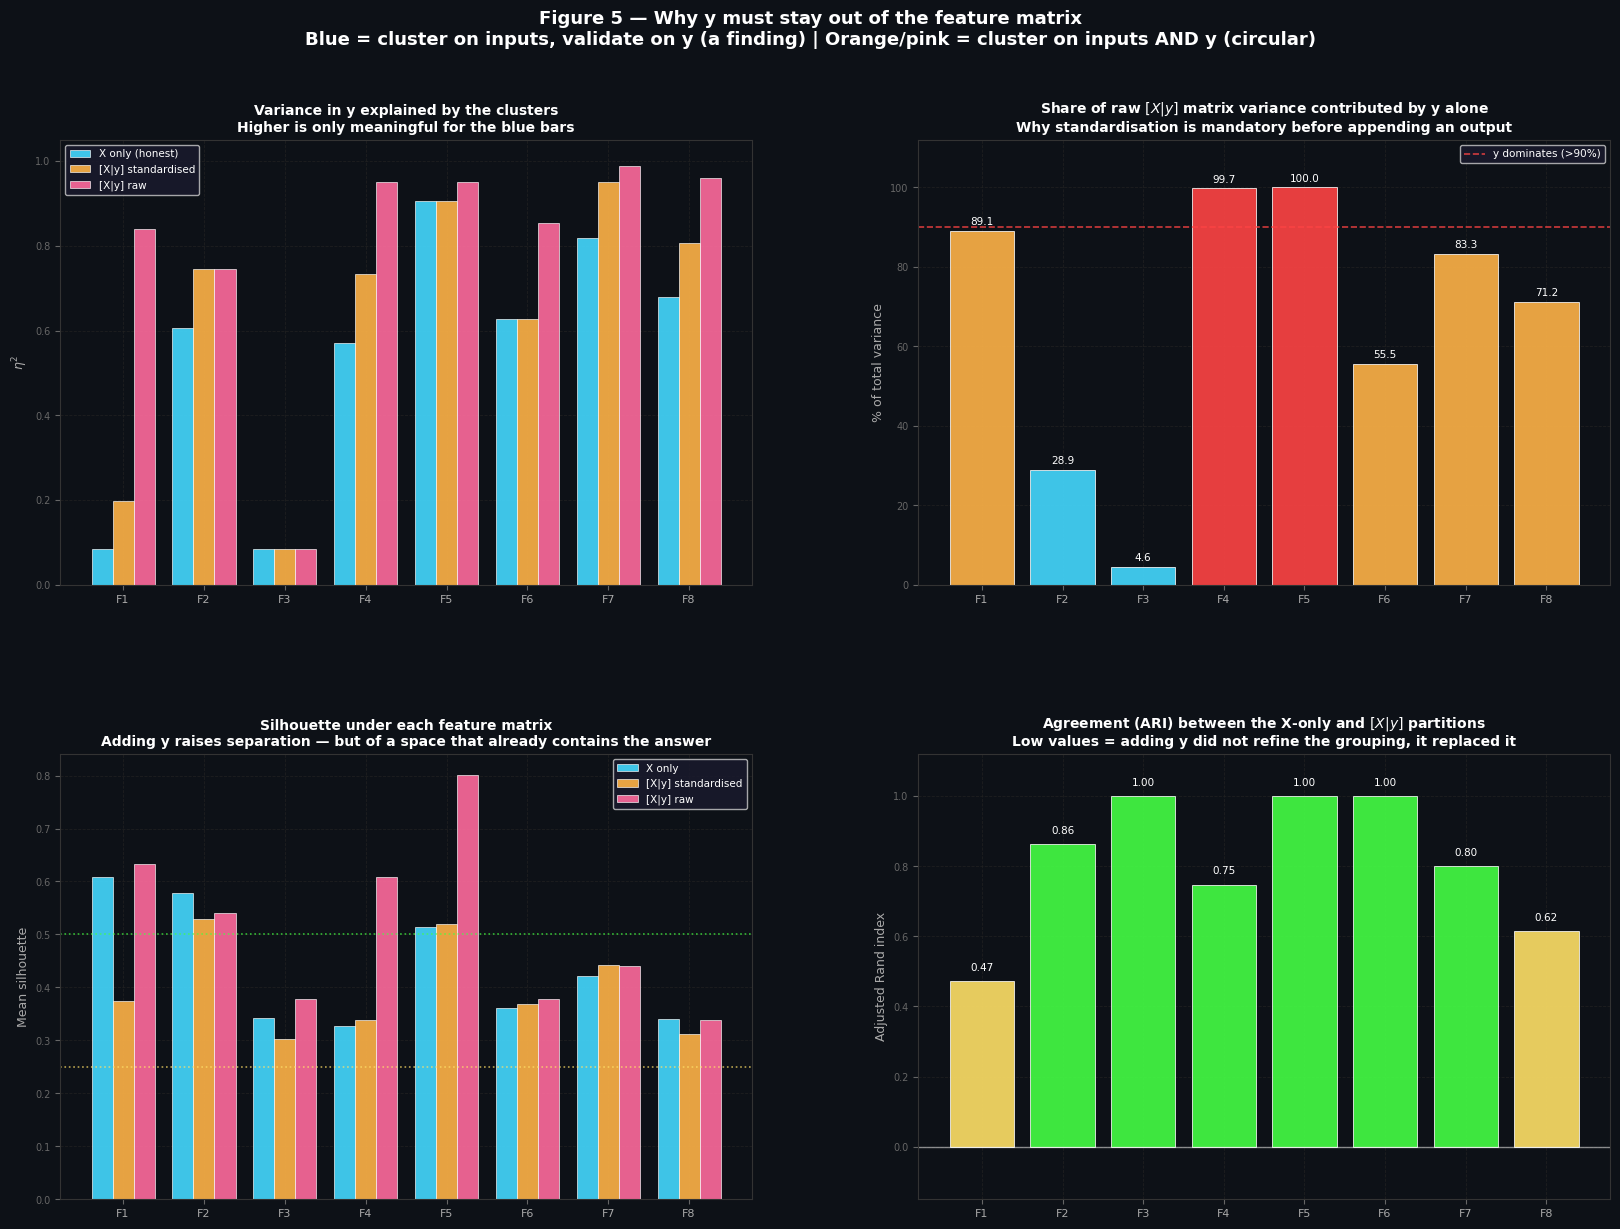

✓ Saved clustering_fig5_leakage_experiment.png


In [13]:
fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.24,
                      top=0.875, bottom=0.060)

x = np.arange(len(FIDS))
w = 0.26
names = [f'F{f}' for f in FIDS]

# ── Panel 1: eta^2 under the three setups ─────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
style_ax(ax)
ax.bar(x - w, [LEAK[f]['eta_a'] for f in FIDS], w, label='X only (honest)',
       color='#44d9ff', alpha=0.9, edgecolor='white', lw=0.5)
ax.bar(x,     [LEAK[f]['eta_b'] for f in FIDS], w, label='[X|y] standardised',
       color='#ffb347', alpha=0.9, edgecolor='white', lw=0.5)
ax.bar(x + w, [LEAK[f]['eta_c'] for f in FIDS], w, label='[X|y] raw',
       color='#ff6b9d', alpha=0.9, edgecolor='white', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(names, color=AC, fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_title('Variance in y explained by the clusters\nHigher is only meaningful for the blue bars',
             color=TC, fontsize=10, fontweight='bold')
ax.set_ylabel('$\\eta^2$', color=AC, fontsize=9)
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white')

# ── Panel 2: y's share of raw matrix variance ─────────────────────────────
ax = fig.add_subplot(gs[0, 1])
style_ax(ax)
shares = [LEAK[f]['var_share'] * 100 for f in FIDS]
cols   = ['#ff4444' if s > 90 else '#ffb347' if s > 50 else '#44d9ff' for s in shares]
bars   = ax.bar(x, shares, color=cols, alpha=0.9, edgecolor='white', lw=0.6)
for b, s in zip(bars, shares):
    ax.text(b.get_x() + b.get_width() / 2, s + 1.5, f'{s:.1f}',
            ha='center', color='white', fontsize=7.5)
ax.axhline(90, color='#ff4444', ls='--', lw=1.2, alpha=0.8, label='y dominates (>90%)')
ax.set_xticks(x); ax.set_xticklabels(names, color=AC, fontsize=8)
ax.set_ylim(0, 112)
ax.set_title('Share of raw $[X|y]$ matrix variance contributed by y alone\n'
             'Why standardisation is mandatory before appending an output',
             color=TC, fontsize=10, fontweight='bold')
ax.set_ylabel('% of total variance', color=AC, fontsize=9)
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white')

# ── Panel 3: silhouette under the three setups ────────────────────────────
ax = fig.add_subplot(gs[1, 0])
style_ax(ax)
ax.bar(x - w, [LEAK[f]['sil_a'] for f in FIDS], w, label='X only',
       color='#44d9ff', alpha=0.9, edgecolor='white', lw=0.5)
ax.bar(x,     [LEAK[f]['sil_b'] for f in FIDS], w, label='[X|y] standardised',
       color='#ffb347', alpha=0.9, edgecolor='white', lw=0.5)
ax.bar(x + w, [LEAK[f]['sil_c'] for f in FIDS], w, label='[X|y] raw',
       color='#ff6b9d', alpha=0.9, edgecolor='white', lw=0.5)
ax.axhline(0.50, color='#44ff44', ls=':', lw=1.2, alpha=0.7)
ax.axhline(0.25, color='#ffe066', ls=':', lw=1.2, alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(names, color=AC, fontsize=8)
ax.set_title('Silhouette under each feature matrix\n'
             'Adding y raises separation — but of a space that already contains the answer',
             color=TC, fontsize=10, fontweight='bold')
ax.set_ylabel('Mean silhouette', color=AC, fontsize=9)
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white')

# ── Panel 4: how far the partitions actually move ─────────────────────────
ax = fig.add_subplot(gs[1, 1])
style_ax(ax)
ari = [LEAK[f]['ari_ab'] for f in FIDS]
cols = ['#44ff44' if a >= 0.7 else '#ffe066' if a >= 0.4 else '#ff4444' for a in ari]
bars = ax.bar(x, ari, color=cols, alpha=0.9, edgecolor='white', lw=0.6)
for b, a in zip(bars, ari):
    ax.text(b.get_x() + b.get_width() / 2,
            a + (0.03 if a >= 0 else -0.06), f'{a:.2f}',
            ha='center', color='white', fontsize=7.5)
ax.axhline(0, color='white', lw=1, alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(names, color=AC, fontsize=8)
ax.set_ylim(min(-0.15, min(ari) - 0.1), 1.12)
ax.set_title('Agreement (ARI) between the X-only and $[X|y]$ partitions\n'
             'Low values = adding y did not refine the grouping, it replaced it',
             color=TC, fontsize=10, fontweight='bold')
ax.set_ylabel('Adjusted Rand index', color=AC, fontsize=9)

fig.suptitle(
    'Figure 5 — Why y must stay out of the feature matrix\n'
    'Blue = cluster on inputs, validate on y (a finding) | '
    'Orange/pink = cluster on inputs AND y (circular)',
    color='white', fontsize=13, fontweight='bold', y=0.975)

plt.savefig('clustering_fig5_leakage_experiment.png', dpi=140,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Saved clustering_fig5_leakage_experiment.png')

---
## Section 7 — DBSCAN: density, and the points that belong to no cluster

K-Means forces every observation into a group. DBSCAN does not — it grows clusters through
dense neighbourhoods and labels whatever is left over as **noise** ($-1$).

For a Bayesian-optimisation design, the noise label is arguably the more useful output.
An isolated point is a place the design has left thin: either a region the acquisition
function visited once and abandoned, or a corner the space-filling design reached and
never revisited.

**`eps` is the whole ballgame.** Too small and everything is noise; too large and everything
is one cluster. Rather than assert a value, the cell below sweeps `eps` over a range derived
from the data's own nearest-neighbour distances and keeps the value maximising silhouette
among the non-noise points, subject to finding at least two clusters and leaving at least
60% of the points clustered.

**Expect DBSCAN to struggle here**, and expect that to be informative. Density-based clustering
needs density contrast, and a space-filling design is engineered to have none.

### Cell 14 — Sweep `eps` and fit DBSCAN per function

In [14]:
from sklearn.neighbors import NearestNeighbors

print('=' * 100)
print('  DBSCAN — density-based clustering with an eps sweep')
print('=' * 100)

DBS = {}

for fid in FIDS:
    d = DATA[fid]
    Z = KM[fid]['Z']
    n = len(Z)
    min_samples = max(3, min(5, d['dim']))

    # Candidate eps range from the k-th nearest-neighbour distance distribution
    nn = NearestNeighbors(n_neighbors=min(min_samples, n - 1)).fit(Z)
    kdist = np.sort(nn.kneighbors(Z)[0][:, -1])
    eps_grid = np.linspace(max(kdist.min(), 1e-3), kdist.max() * 1.6, 40)

    best = None
    for eps in eps_grid:
        lab = DBSCAN(eps=float(eps), min_samples=min_samples).fit_predict(Z)
        core = lab >= 0
        n_cl = len(set(lab[core]))
        if n_cl < 2 or core.sum() < 0.60 * n:
            continue
        try:
            s = float(silhouette_score(Z[core], lab[core]))
        except ValueError:
            continue
        if best is None or s > best['sil']:
            best = dict(eps=float(eps), labels=lab, sil=s,
                        n_clusters=n_cl, n_noise=int((~core).sum()))

    if best is None:                     # no eps produced a usable partition
        DBS[fid] = dict(ok=False, kdist=kdist, min_samples=min_samples)
        print(f"\n  F{fid} ({d['dim']}D): ✗ no eps produced ≥2 clusters covering ≥60% of points")
        print(f"      → the design is close to uniform; there is no density contrast to find")
        continue

    eta, p = eta_squared_test(d['y'], best['labels'])
    best.update(ok=True, eta2=eta, pval=p, kdist=kdist, min_samples=min_samples)
    DBS[fid] = best

    y = d['y']
    noise_m = best['labels'] < 0
    print(f"\n  F{fid} ({d['dim']}D, n={n}): eps={best['eps']:.3f}, min_samples={min_samples}")
    print(f"      clusters={best['n_clusters']}, noise={best['n_noise']} "
          f"({best['n_noise']/n*100:.0f}%), silhouette={best['sil']:.3f}")
    print(f"      eta^2={eta:.3f} (p={p:.4f})")
    if noise_m.any():
        print(f"      mean y of noise points   : {y[noise_m].mean():.4f}")
        print(f"      mean y of clustered points: {y[~noise_m].mean():.4f}")
        if y[noise_m].mean() > y[~noise_m].mean():
            print(f"      ↳ the isolated points score BETTER on average — "
                  f"sparsely sampled regions may be worth revisiting")

  DBSCAN — density-based clustering with an eps sweep

  F1 (2D): ✗ no eps produced ≥2 clusters covering ≥60% of points
      → the design is close to uniform; there is no density contrast to find

  F2 (2D, n=23): eps=0.646, min_samples=3
      clusters=3, noise=7 (30%), silhouette=0.775
      eta^2=0.876 (p=0.0005)
      mean y of noise points   : 0.1399
      mean y of clustered points: 0.4744

  F3 (3D, n=28): eps=0.948, min_samples=3
      clusters=2, noise=10 (36%), silhouette=0.510
      eta^2=0.078 (p=0.2279)
      mean y of noise points   : -0.1382
      mean y of clustered points: -0.0661

  F4 (4D, n=43): eps=1.530, min_samples=4
      clusters=2, noise=12 (28%), silhouette=0.317
      eta^2=0.034 (p=0.3228)
      mean y of noise points   : -22.7929
      mean y of clustered points: -8.1196

  F5 (4D, n=33): eps=1.130, min_samples=4
      clusters=4, noise=10 (30%), silhouette=0.708
      eta^2=0.881 (p=0.0005)
      mean y of noise points   : 68.7393
      mean y of cluster

### Cell 15 — Figure 6: DBSCAN partitions, with noise highlighted

Red ✕ marks noise. Where DBSCAN failed to find a usable partition at any `eps`,
the panel instead shows the $k$-nearest-neighbour distance curve — a flat curve with no
knee is the visual signature of a design with no density contrast, which is precisely
what a well-constructed space-filling design should produce.

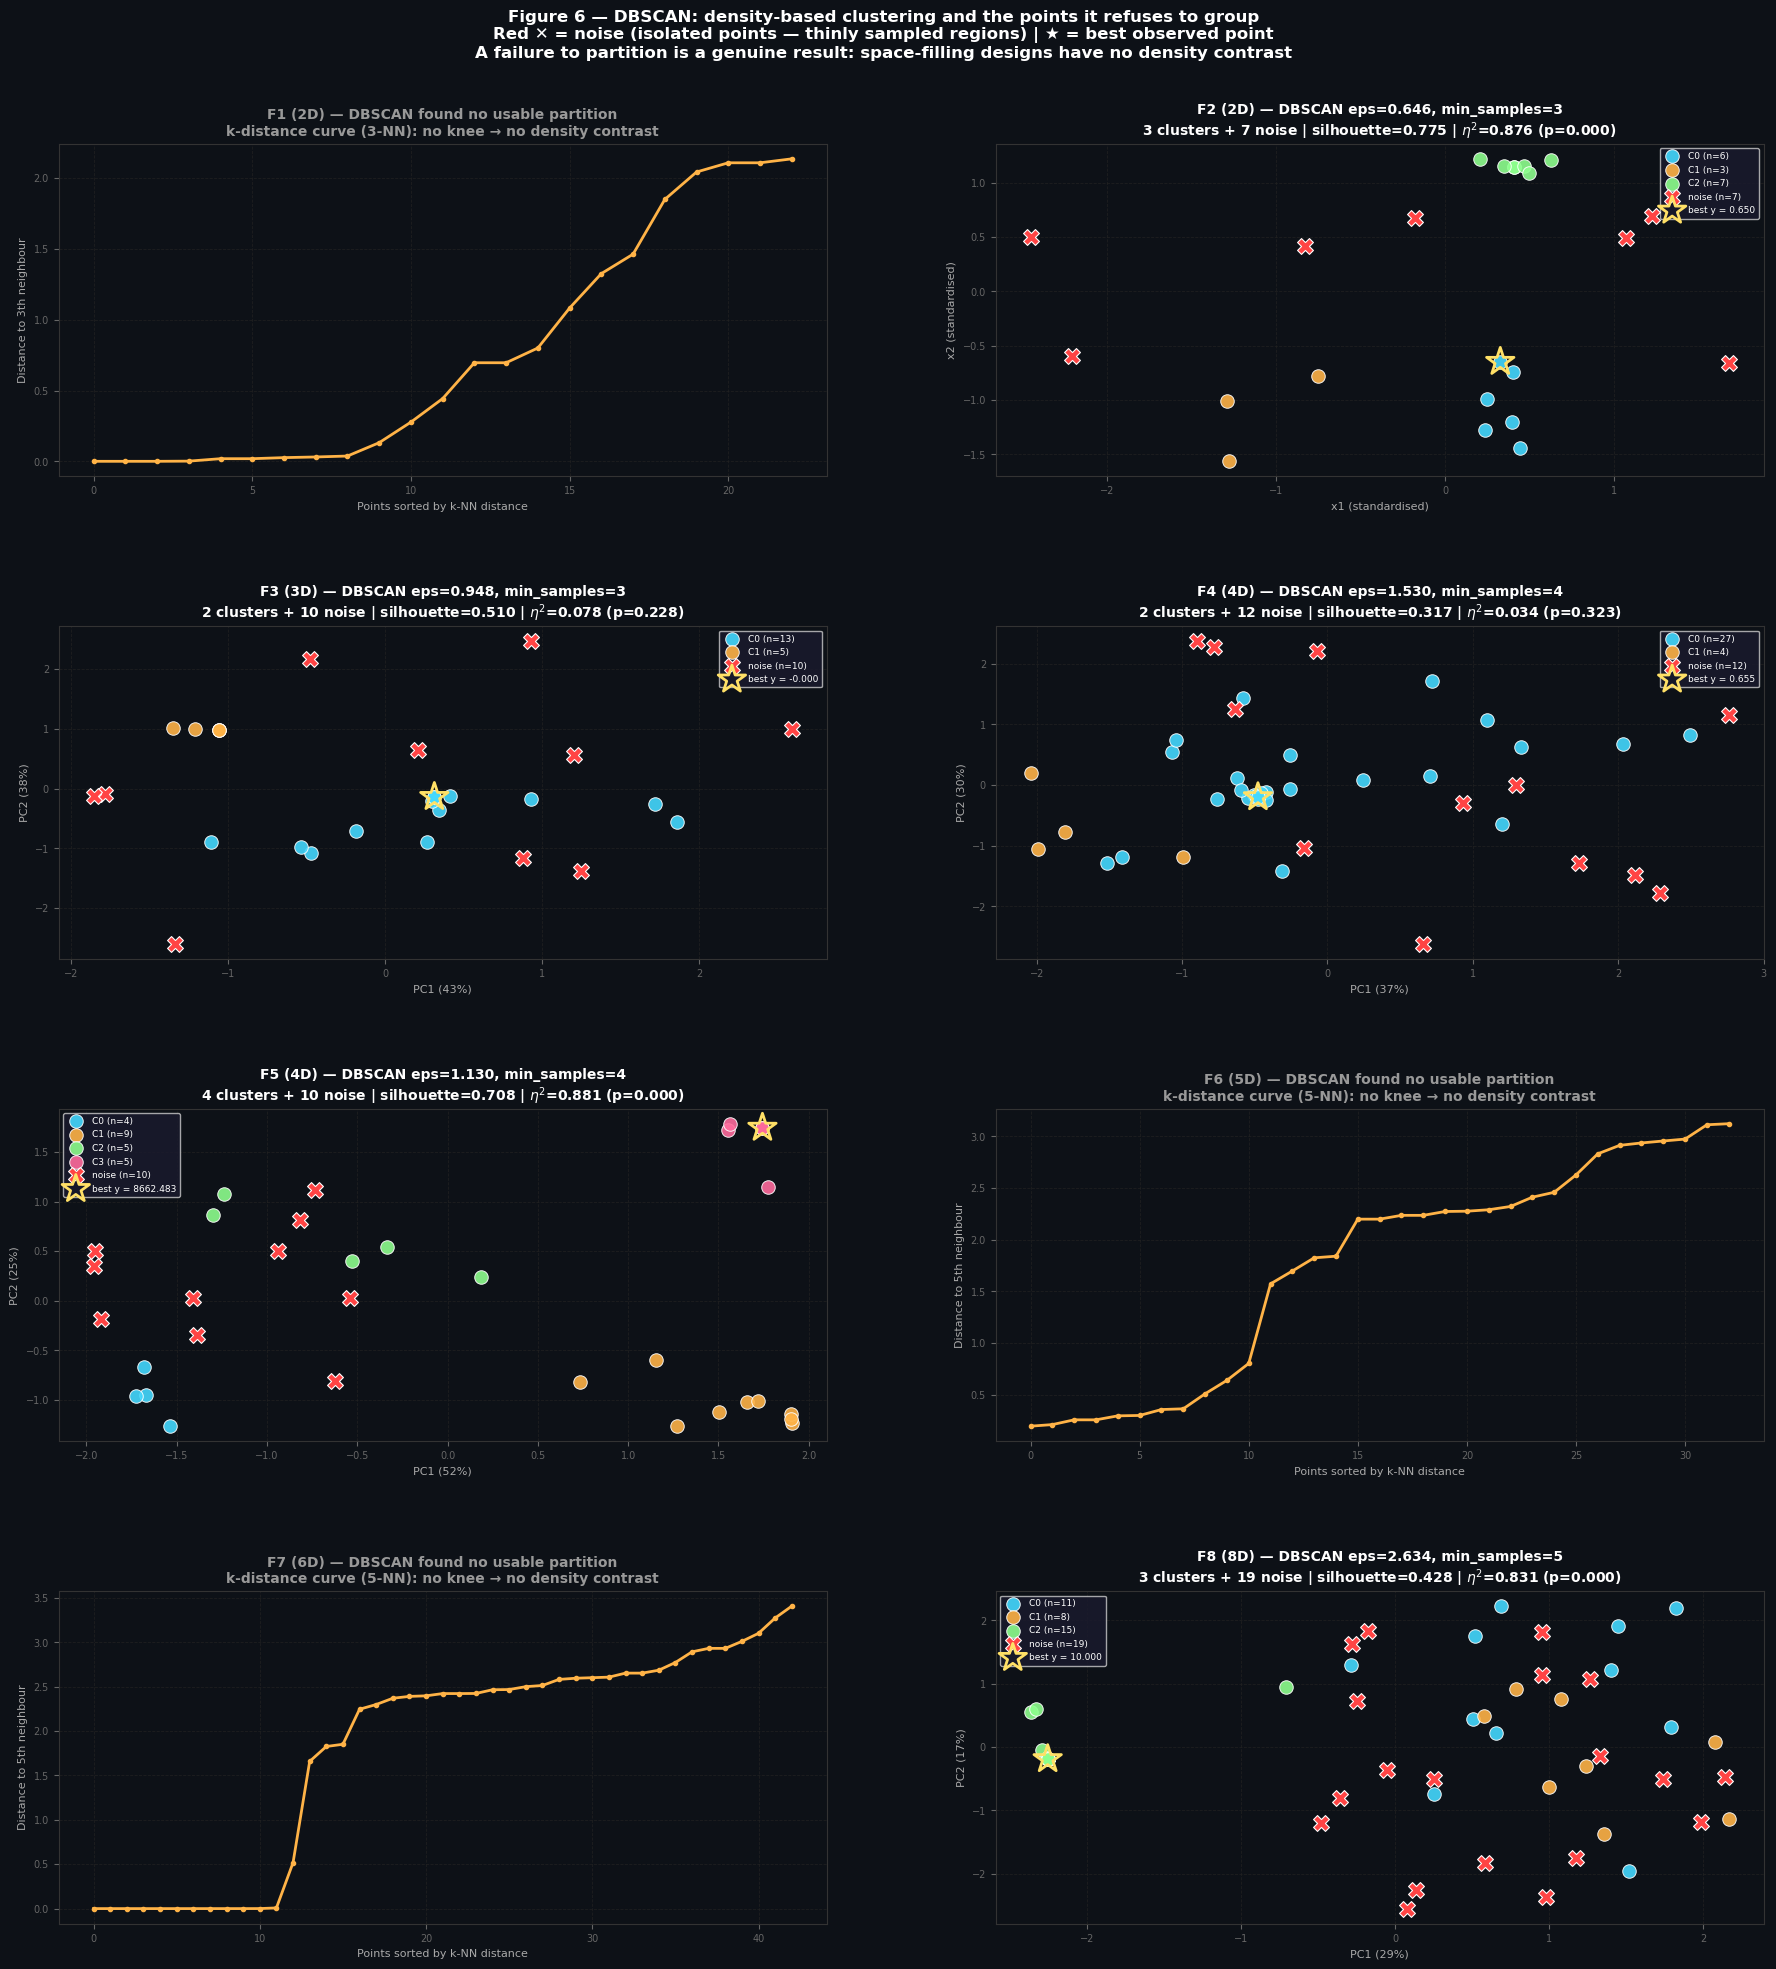

✓ Saved clustering_fig6_dbscan.png


In [15]:
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.22,
                      top=0.925, bottom=0.035)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    ax = fig.add_subplot(gs[r, c])
    style_ax(ax)

    d   = DATA[fid]
    res = DBS[fid]

    if not res['ok']:
        kd = res['kdist']
        ax.plot(np.arange(len(kd)), kd, color='#ffb347', lw=2, marker='o', ms=3)
        ax.set_title(f"F{fid} ({d['dim']}D) — DBSCAN found no usable partition\n"
                     f"k-distance curve ({res['min_samples']}-NN): no knee → no density contrast",
                     color='#999999', fontsize=10, fontweight='bold')
        ax.set_xlabel('Points sorted by k-NN distance', color=AC, fontsize=8)
        ax.set_ylabel(f"Distance to {res['min_samples']}th neighbour", color=AC, fontsize=8)
        continue

    coords, evr, lab_x, lab_y = PCA_INFO[fid]
    lab   = res['labels']
    noise = lab < 0

    for cl in sorted(set(lab[~noise])):
        m = lab == cl
        ax.scatter(coords[m, 0], coords[m, 1], s=95, alpha=0.9,
                   color=CLUSTER_COLORS[int(cl) % len(CLUSTER_COLORS)],
                   edgecolor='white', lw=0.7, label=f'C{cl} (n={m.sum()})')
    if noise.any():
        ax.scatter(coords[noise, 0], coords[noise, 1], s=130, marker='X',
                   color=NOISE_COLOR, edgecolor='white', lw=0.8,
                   label=f'noise (n={noise.sum()})', zorder=6)

    b = int(np.argmax(d['y']))
    ax.scatter([coords[b, 0]], [coords[b, 1]], marker='*', s=430,
               facecolor='none', edgecolor='#ffe066', lw=2, zorder=7,
               label=f'best y = {d["y"][b]:.3f}')

    ax.set_title(f"F{fid} ({d['dim']}D) — DBSCAN eps={res['eps']:.3f}, "
                 f"min_samples={res['min_samples']}\n"
                 f"{res['n_clusters']} clusters + {res['n_noise']} noise | "
                 f"silhouette={res['sil']:.3f} | $\\eta^2$={res['eta2']:.3f} (p={res['pval']:.3f})",
                 color=TC, fontsize=10, fontweight='bold')
    ax.set_xlabel(lab_x, color=AC, fontsize=8)
    ax.set_ylabel(lab_y, color=AC, fontsize=8)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='best')

fig.suptitle(
    'Figure 6 — DBSCAN: density-based clustering and the points it refuses to group\n'
    'Red ✕ = noise (isolated points — thinly sampled regions) | ★ = best observed point\n'
    'A failure to partition is a genuine result: space-filling designs have no density contrast',
    color='white', fontsize=12, fontweight='bold', y=0.992)

plt.savefig('clustering_fig6_dbscan.png', dpi=140,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Saved clustering_fig6_dbscan.png')

---
## Section 8 — Describing the promising region (and why it is not a query)

For each function we take the highest-scoring cluster from Section 3 and describe it in
original input units: its centroid, its per-dimension range, and its best member.

**This is a description, not a recommendation.** The distinction matters, and it is the
reason this notebook sits in the diagnostics family:

- A cluster centroid summarises **where good points have already been found**.
  It contains no notion of uncertainty, so it cannot distinguish "reliably good"
  from "we have only looked here once".
- Bayesian optimisation needs the *exploration* term that a GP's $\sigma(\mathbf{x})$
  supplies. A centroid has no $\sigma$. Following one would re-sample the middle of a
  region already characterised — the definition of pure exploitation.
- The cluster with the best mean $y$ can easily be the one with three points in it.
  Section 3's $p$-values are the guard against reading too much into that.

Used properly, this table is a **cross-check**: if the best cluster's centroid points the
same way as the GP's next query and A2's logistic-regression coefficients, three independent
methods agree and confidence rises. Where they disagree, the GP wins — it is the only one
of the three that models the response surface.

### Cell 16 — Best-cluster region of interest, all eight functions

In [16]:
print('=' * 104)
print('  REGION OF INTEREST — highest-mean-y cluster per function, in original input units')
print('  ⚠ DESCRIPTIVE ONLY — no uncertainty term, therefore not a query proposal')
print('=' * 104)

ROI = {}

for fid in FIDS:
    d    = DATA[fid]
    res  = KM[fid]
    prof = res['profile']
    best_cluster = int(prof.iloc[0]['cluster'])
    m = res['labels'] == best_cluster

    Xc      = d['X'][m]
    yc      = d['y'][m]
    centroid = Xc.mean(axis=0)
    lo, hi   = Xc.min(axis=0), Xc.max(axis=0)
    best_pt  = Xc[int(np.argmax(yc))]

    ROI[fid] = dict(cluster=best_cluster, n=int(m.sum()), centroid=centroid,
                    lo=lo, hi=hi, best_pt=best_pt, y_best=float(yc.max()),
                    y_mean=float(yc.mean()))

    trust = ('reliable'   if (res['pval'] < 0.05 and m.sum() >= 5) else
             'fragile — few points' if m.sum() < 5 else
             'not significant')

    print(f"\n{'─' * 104}")
    print(f"  F{fid} ({d['dim']}D) — cluster C{best_cluster}, n={m.sum()} of {len(d['y'])} "
          f"| eta^2={res['eta2']:.3f}, p={res['pval']:.4f} → {trust}")
    print(f"{'─' * 104}")

    tbl = pd.DataFrame({
        'dim':      d['xcols'],
        'centroid': np.round(centroid, 4),
        'min':      np.round(lo, 4),
        'max':      np.round(hi, 4),
        'width':    np.round(hi - lo, 4),
        'best pt':  np.round(best_pt, 4),
    })
    print(tbl.to_string(index=False))
    print(f"    mean y in cluster = {yc.mean():.4f} | best y in cluster = {yc.max():.4f}")
    print(f"    centroid (portal format): "
          f"{'-'.join(f'{v:.6f}' for v in centroid)}")
    print(f"    best member (portal format): "
          f"{'-'.join(f'{v:.6f}' for v in best_pt)}")

print('\n' + '=' * 104)
print('  Reminder: these coordinates describe where good observations already sit.')
print('  They carry no uncertainty estimate and must not be submitted as queries.')
print('  Use them only to check whether the GP\'s proposal points somewhere consistent.')
print('=' * 104)

  REGION OF INTEREST — highest-mean-y cluster per function, in original input units
  ⚠ DESCRIPTIVE ONLY — no uncertainty term, therefore not a query proposal

────────────────────────────────────────────────────────────────────────────────────────────────────────
  F1 (2D) — cluster C0, n=20 of 23 | eta^2=0.084, p=0.1844 → not significant
────────────────────────────────────────────────────────────────────────────────────────────────────────
dim  centroid    min    max  width  best pt
 x1    0.6032 0.1239 0.8839 0.7600   0.6285
 x2    0.6491 0.2647 0.8799 0.6152   0.6285
    mean y in cluster = 0.6766 | best y in cluster = 2.0000
    centroid (portal format): 0.603155-0.649111
    best member (portal format): 0.628468-0.628468

────────────────────────────────────────────────────────────────────────────────────────────────────────
  F2 (2D) — cluster C2, n=7 of 23 | eta^2=0.605, p=0.0005 → reliable
───────────────────────────────────────────────────────────────────────────────────────

---
## Section 9 — Summary, honest limitations, and what to put in the report

### Cell 17 — Master results table

In [17]:
print('=' * 118)
print('  MASTER SUMMARY — unsupervised clustering across all eight functions')
print('=' * 118)

summary = []
for fid in FIDS:
    d, res, h = DATA[fid], KM[fid], HIER[fid]
    db = DBS[fid]
    sig = res['pval'] < 0.05
    summary.append({
        'Fn':            f'F{fid}',
        'Dim':           d['dim'],
        'N':             len(d['y']),
        'N/dim':         round(len(d['y']) / d['dim'], 1),
        'K':             res['k'],
        'Silh.':         round(res['sil'], 3),
        'Structure':     silhouette_verdict(res['sil']),
        'eta2':          round(res['eta2'], 3),
        'p':             round(res['pval'], 4),
        'Signif.':       '✓' if sig else '✗',
        'Ward ARI':      round(float(adjusted_rand_score(res['labels'], h['labels'])), 3),
        'Cophen.':       round(h['coph'], 3),
        'DBSCAN':        (f"{db['n_clusters']}cl/{db['n_noise']}n" if db['ok'] else 'failed'),
    })

SUMMARY = pd.DataFrame(summary)
print(SUMMARY.to_string(index=False))

n_sig = int((SUMMARY['Signif.'] == '✓').sum())
print(f"\n  Functions where the X-only partition explains y "
      f"significantly better than chance: {n_sig} of {len(FIDS)}")
if n_sig:
    print("    → " + ", ".join(SUMMARY.loc[SUMMARY['Signif.'] == '✓', 'Fn'].tolist()))

print(f"\n  Mean silhouette across all eight: {SUMMARY['Silh.'].mean():.3f} "
      f"({silhouette_verdict(SUMMARY['Silh.'].mean())})")
print(f"  Mean eta^2 across all eight     : {SUMMARY['eta2'].mean():.3f}")

# Does cluster structure degrade with dimension, as theory predicts?
corr = float(np.corrcoef(SUMMARY['Dim'], SUMMARY['Silh.'])[0, 1])
print(f"\n  Correlation between input dimension and silhouette: {corr:+.3f}")
print("    Negative → cluster structure degrades as dimension rises,")
print("    which is the curse of dimensionality showing up in our own data.")

  MASTER SUMMARY — unsupervised clustering across all eight functions
Fn  Dim  N  N/dim  K  Silh.            Structure  eta2      p Signif.  Ward ARI  Cophen.  DBSCAN
F1    2 23   11.5  2  0.608 reasonable structure 0.084 0.1844       ✗     1.000    0.918  failed
F2    2 23   11.5  3  0.577 reasonable structure 0.605 0.0005       ✓     0.719    0.779  3cl/7n
F3    3 28    9.3  2  0.342       weak structure 0.085 0.1229       ✗     0.599    0.576 2cl/10n
F4    4 43   10.8  4  0.327       weak structure 0.570 0.0005       ✓     0.825    0.696 2cl/12n
F5    4 33    8.2  3  0.514 reasonable structure 0.905 0.0005       ✓     1.000    0.829 4cl/10n
F6    5 33    6.6  3  0.362       weak structure 0.627 0.0005       ✓     1.000    0.727  failed
F7    6 43    7.2  8  0.422       weak structure 0.817 0.0005       ✓     0.819    0.792  failed
F8    8 53    6.6  9  0.340       weak structure 0.679 0.0005       ✓     0.869    0.607 3cl/19n

  Functions where the X-only partition explains y signif

### 9.1 What the analysis actually established

Fill this in from the table above — the numbers change every week as new observations arrive,
so the narrative should be re-read rather than copied forward.

The three questions worth answering in the report:

1. **Which functions showed significant geometric structure?**
   Those are the ones where the promising region is a contiguous, convex-ish blob.
   They are the candidates for a localised search strategy.

2. **Did K-Means and Ward agree (ARI column)?**
   Agreement means the structure is a property of the data. Disagreement means it is a
   property of the algorithm, and should not be built upon.

3. **Did silhouette fall as dimension rose?**
   If the correlation printed above is strongly negative, that is a clean empirical
   demonstration of the curse of dimensionality using our own eight functions —
   worth a paragraph in its own right.

### 9.2 Limitations — state these explicitly

- **Sample size.** Between 20 and 50 observations per function. Clustering theory generally
  wants an order of magnitude more. Every partition here is provisional, which is why every
  claim is paired with a permutation $p$-value rather than an assertion.
- **Space-filling designs resist clustering by construction.** Latin hypercube and Sobol
  sequences are built to spread points evenly. Low silhouettes are the design working
  correctly, not the method failing.
- **The weekly points are not independent samples.** Bayesian optimisation deliberately
  concentrates queries in promising regions, so the combined dataset is a biased sample of
  the domain. Any cluster structure partly reflects *the GP's search history* rather than
  the function's landscape — an important caveat when interpreting the best cluster.
- **PCA projections lose information.** Check the explained-variance percentages from
  Cell 9 before drawing conclusions from any high-dimensional panel.
- **$\eta^2$ is biased upward** by small $n$ and large $K$. This is exactly why the
  permutation test is reported alongside it, and why a large $\eta^2$ with $p > 0.05$
  should be read as "no finding".
- **Clustering cannot propose a query.** It has no uncertainty model. Section 8's
  coordinates are descriptive only.

### 9.3 How this notebook relates to the rest of the project

| Notebook | Paradigm | Uses $y$ as | Can propose a query? |
|---|---|---|---|
| A1 — SVM | Supervised | Manufactured label | No (diagnostic) |
| A2 — Logistic regression | Supervised | Manufactured label | No (diagnostic) |
| **A4 — Clustering (this)** | **Unsupervised** | **External validator only** | **No (diagnostic)** |
| 05 — GP suggest engine | Bayesian surrogate | Regression target | **Yes** |

The three diagnostics answer different questions about the same data, and their value is
in *triangulation*. Where the logistic-regression direction, the best cluster's centroid,
and the GP's proposal all point the same way, confidence is high. Where they conflict,
the GP takes precedence — it is the only method here that models the response surface and
quantifies its own uncertainty.

### 9.4 Reproducibility

Every stochastic component is seeded with `RANDOM_STATE = 42`: K-Means initialisation
(with `n_init=10` restarts), PCA, the permutation tests, and the plot jitter.
Re-running the notebook on the same CSV reproduces every number and figure exactly.
Figures are written alongside the notebook as `clustering_fig1` … `clustering_fig6`.

In [18]:
print('=' * 96)
print('  ✓ NOTEBOOK COMPLETE')
print('=' * 96)
print(f'  Functions analysed : {len(FIDS)}  (F1-F8)')
print(f'  Observations       : {len(OBS)}')
print(f'  Methods            : K-Means, Ward hierarchical, DBSCAN, PCA')
print(f'  Validation         : silhouette, cophenetic r, ARI, eta^2 + permutation test')
print(f'  Random state       : {RANDOM_STATE}   (fully reproducible)')
print()
print('  Figures written to the notebook folder:')
for i, name in enumerate([
    'elbow_silhouette', 'cluster_profiles', 'pca_gallery',
    'dendrograms', 'leakage_experiment', 'dbscan'], start=1):
    print(f'    clustering_fig{i}_{name}.png')
print()
print('  Reminder: this is a diagnostic notebook. It describes structure; it does not')
print('  select queries. The GP surrogate in notebook 05 remains the decision engine.')

  ✓ NOTEBOOK COMPLETE
  Functions analysed : 8  (F1-F8)
  Observations       : 279
  Methods            : K-Means, Ward hierarchical, DBSCAN, PCA
  Validation         : silhouette, cophenetic r, ARI, eta^2 + permutation test
  Random state       : 42   (fully reproducible)

  Figures written to the notebook folder:
    clustering_fig1_elbow_silhouette.png
    clustering_fig2_cluster_profiles.png
    clustering_fig3_pca_gallery.png
    clustering_fig4_dendrograms.png
    clustering_fig5_leakage_experiment.png
    clustering_fig6_dbscan.png

  Reminder: this is a diagnostic notebook. It describes structure; it does not
  select queries. The GP surrogate in notebook 05 remains the decision engine.
